In [ ]:
#1- Handling Missing Values - IT24100500

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load your dataset
file_path = 'C:\\Users\\ASUS\\health_lifestyle_classification.csv'
df = pd.read_csv(file_path)

# Step 3: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support

Missing values per column:
survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support

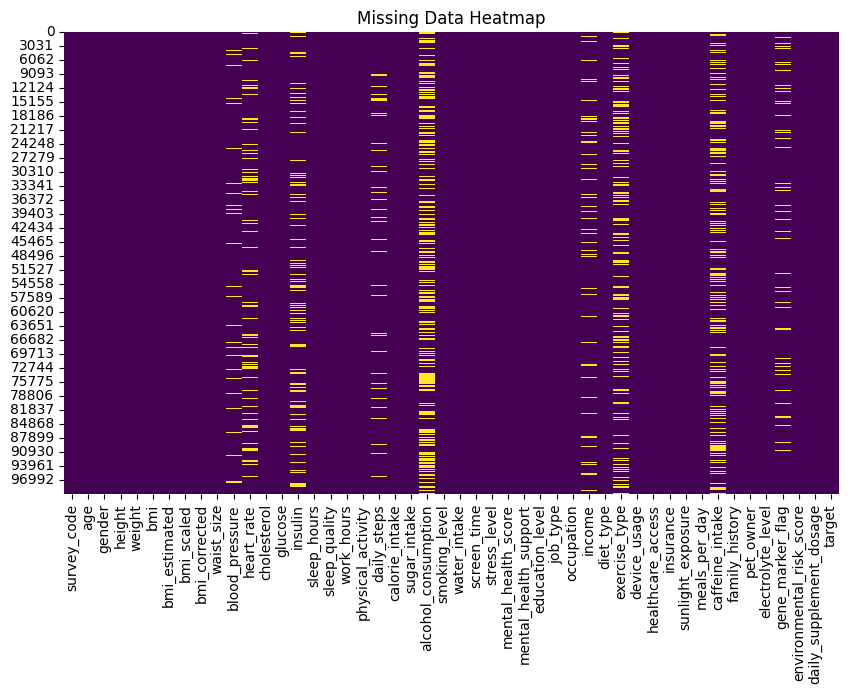


Processing column: heart_rate
Original missing: 14003, Mean used: 74.97


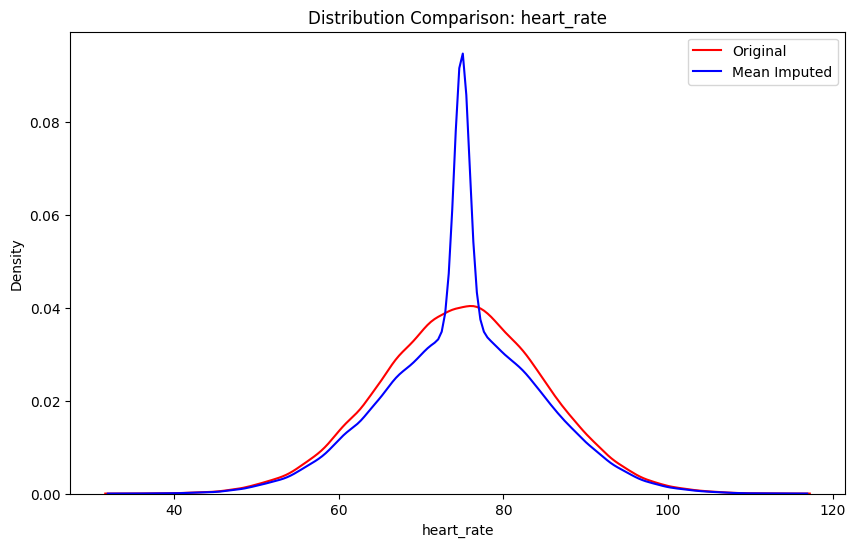


Processing column: blood_pressure
Original missing: 7669, Mean used: 119.98


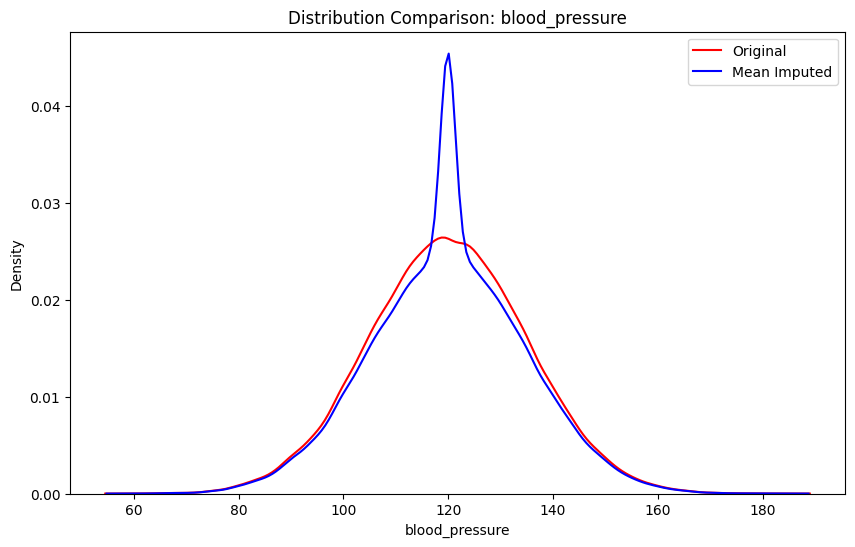


Processing column: daily_steps
Original missing: 8329, Mean used: 7012.93


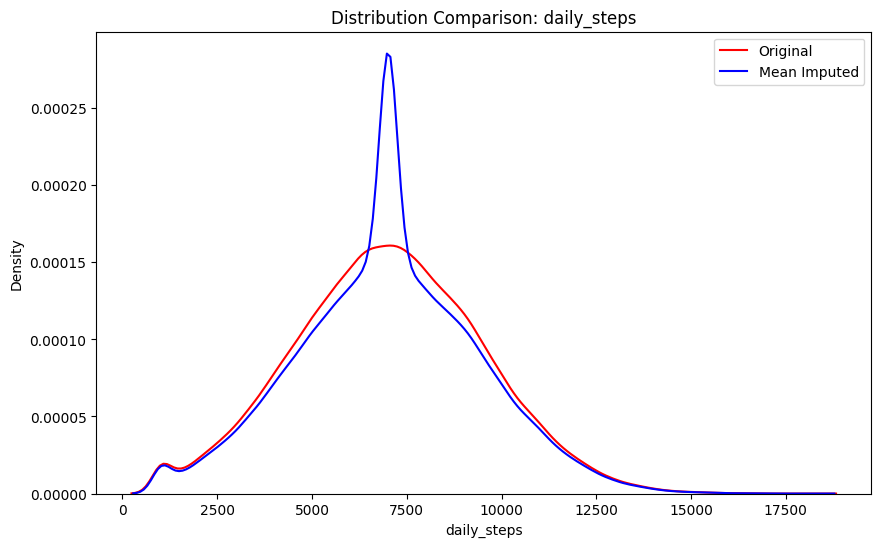

In [3]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load your dataset
file_path = 'C:\\Users\\ASUS\\health_lifestyle_classification.csv'
df = pd.read_csv(file_path)

# Step 3: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Step 4: Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Step 5: Define target columns
target_cols = ['heart_rate', 'blood_pressure', 'daily_steps']

# Step 6: Impute and compare distributions
for col in target_cols:
    print(f"\nProcessing column: {col}")
    
    # Convert to numeric (coerce errors to NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Fill missing values with mean
    mean_value = df[col].mean()
    imputed_col = col + '_mean'
    df[imputed_col] = df[col].fillna(mean_value)
    
    # Print summary stats
    print(f"Original missing: {df[col].isnull().sum()}, Mean used: {mean_value:.2f}")
    
    # Plot distributions if variance exists
    plt.figure(figsize=(10, 6))
    plotted = False
    if df[col].var() > 0:
        sns.kdeplot(df[col], label='Original', color='red')
        plotted = True
    else:
        print(f"Skipping KDE for {col} due to zero variance.")
    
    if df[imputed_col].var() > 0:
        sns.kdeplot(df[imputed_col], label='Mean Imputed', color='blue')
        plotted = True
    else:
        print(f"Skipping KDE for {imputed_col} due to zero variance.")
    
    if plotted:
        plt.title(f'Distribution Comparison: {col}')
        plt.legend()
        plt.show()


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support

In [5]:
# Define original columns to drop
original_cols = ['heart_rate', 'blood_pressure', 'daily_steps']

# Drop them from the DataFrame
df.drop(columns=original_cols, inplace=True)

# Confirm they're gone
print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'sleep_quality',
       'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
       'alcohol_consumption', 'smoking_level', 'water_intake', 'screen_time',
       'stress_level', 'mental_health_score', 'mental_health_support',
       'education_level', 'job_type', 'occupation', 'income', 'diet_type',
       'exercise_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'caffeine_intake',
       'family_history', 'pet_owner', 'electrolyte_level', 'gene_marker_flag',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate_mean', 'blood_pressure_mean', 'daily_steps_mean'],
      dtype='object')


In [6]:
df.rename(columns={
    'heart_rate_mean': 'heart_rate',
    'blood_pressure_mean': 'blood_pressure',
    'daily_steps_mean': 'daily_steps'
}, inplace=True)

# ✅ Confirm the change
print("Updated column names:")
print(df.columns)

Updated column names:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'sleep_quality',
       'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
       'alcohol_consumption', 'smoking_level', 'water_intake', 'screen_time',
       'stress_level', 'mental_health_score', 'mental_health_support',
       'education_level', 'job_type', 'occupation', 'income', 'diet_type',
       'exercise_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'caffeine_intake',
       'family_history', 'pet_owner', 'electrolyte_level', 'gene_marker_flag',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate', 'blood_pressure', 'daily_steps'],
      dtype='object')


In [7]:
# Define original columns to drop
original_cols = ['insulin', 'alcohol_consumption', 'income','caffeine_intake','gene_marker_flag','exercise_type']

# Drop them from the DataFrame
df.drop(columns=original_cols, inplace=True)

# Confirm they're gone
print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'sleep_hours', 'sleep_quality', 'work_hours',
       'physical_activity', 'calorie_intake', 'sugar_intake', 'smoking_level',
       'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
       'mental_health_support', 'education_level', 'job_type', 'occupation',
       'diet_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'family_history', 'pet_owner',
       'electrolyte_level', 'environmental_risk_score',
       'daily_supplement_dosage', 'target', 'heart_rate', 'blood_pressure',
       'daily_steps'],
      dtype='object')


In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                 0
age                         0
gender                      0
height                      0
weight                      0
bmi                         0
bmi_estimated               0
bmi_scaled                  0
bmi_corrected               0
waist_size                  0
cholesterol                 0
glucose                     0
sleep_hours                 0
sleep_quality               0
work_hours                  0
physical_activity           0
calorie_intake              0
sugar_intake                0
smoking_level               0
water_intake                0
screen_time                 0
stress_level                0
mental_health_score         0
mental_health_support       0
education_level             0
job_type                    0
occupation                  0
diet_type                   0
device_usage                0
healthcare_access           0
insurance                   0
sunlight_exposure           0
meals_per_day

In [9]:
df =df.dropna()
df.count()

survey_code                 100000
age                         100000
gender                      100000
height                      100000
weight                      100000
bmi                         100000
bmi_estimated               100000
bmi_scaled                  100000
bmi_corrected               100000
waist_size                  100000
cholesterol                 100000
glucose                     100000
sleep_hours                 100000
sleep_quality               100000
work_hours                  100000
physical_activity           100000
calorie_intake              100000
sugar_intake                100000
smoking_level               100000
water_intake                100000
screen_time                 100000
stress_level                100000
mental_health_score         100000
mental_health_support       100000
education_level             100000
job_type                    100000
occupation                  100000
diet_type                   100000
device_usage        

In [1]:
#2- Encoding Categorical Varaibles - IT24100546 

In [10]:
import pandas as pd
# Now this will work
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)


Categorical columns: ['gender', 'sleep_quality', 'smoking_level', 'mental_health_support', 'education_level', 'job_type', 'occupation', 'diet_type', 'device_usage', 'healthcare_access', 'insurance', 'sunlight_exposure', 'family_history', 'pet_owner', 'target']


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])


In [33]:
df['sleep_quality']

0             Fair
1             Good
2             Poor
3             Good
4             Good
           ...    
99995         Poor
99996    Excellent
99997         Good
99998         Fair
99999         Fair
Name: sleep_quality, Length: 100000, dtype: object

In [12]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
slp_quality = ['Poor', 'Fair', 'Good', 'Excellent']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[slp_quality])

# Apply encoding
df['sleep_quality_encoded'] = oe.fit_transform(df[['sleep_quality']])


In [13]:
df['sleep_quality_encoded']

0        1.0
1        2.0
2        0.0
3        2.0
4        2.0
        ... 
99995    0.0
99996    3.0
99997    2.0
99998    1.0
99999    1.0
Name: sleep_quality_encoded, Length: 100000, dtype: float64

In [14]:
df['smoking_level']

0        Non-smoker
1             Light
2             Heavy
3             Heavy
4             Heavy
            ...    
99995         Light
99996         Light
99997         Heavy
99998    Non-smoker
99999    Non-smoker
Name: smoking_level, Length: 100000, dtype: object

In [15]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
smk_lvl = ['Non-smoker', 'Light', 'Heavy']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[smk_lvl])

# Apply encoding
df['smoking_level_encoded'] = oe.fit_transform(df[['smoking_level']])


In [16]:
df['smoking_level_encoded']

0        0.0
1        1.0
2        2.0
3        2.0
4        2.0
        ... 
99995    1.0
99996    1.0
99997    2.0
99998    0.0
99999    0.0
Name: smoking_level_encoded, Length: 100000, dtype: float64

In [17]:
df['mental_health_support']

0         No
1         No
2         No
3         No
4        Yes
        ... 
99995     No
99996     No
99997    Yes
99998    Yes
99999    Yes
Name: mental_health_support, Length: 100000, dtype: object

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['mental_health_support_encoded'] = le.fit_transform(df['mental_health_support'])

In [19]:
df['education_level']

0                PhD
1        High School
2             Master
3             Master
4             Master
            ...     
99995       Bachelor
99996       Bachelor
99997            PhD
99998         Master
99999            PhD
Name: education_level, Length: 100000, dtype: object

In [20]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
edu_lvl = ['High School', 'Bachelor', 'Master','PhD']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[edu_lvl])

# Apply encoding
df['education_level_encoded'] = oe.fit_transform(df[['education_level']])

In [21]:
df['education_level_encoded']

0        3.0
1        0.0
2        2.0
3        2.0
4        2.0
        ... 
99995    1.0
99996    1.0
99997    3.0
99998    2.0
99999    3.0
Name: education_level_encoded, Length: 100000, dtype: float64

In [22]:
df = pd.get_dummies(df, columns=['job_type', 'diet_type','occupation',], drop_first=True)

In [23]:
df['device_usage']

0            High
1        Moderate
2            High
3             Low
4             Low
           ...   
99995    Moderate
99996        High
99997         Low
99998         Low
99999         Low
Name: device_usage, Length: 100000, dtype: object

In [24]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
dev_usg = ['Low', 'Moderate', 'High']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[dev_usg])

# Apply encoding
df['device_usage_encoded'] = oe.fit_transform(df[['device_usage']])

In [25]:
df['healthcare_access']

0            Poor
1        Moderate
2            Good
3        Moderate
4        Moderate
           ...   
99995        Poor
99996    Moderate
99997        Good
99998        Poor
99999    Moderate
Name: healthcare_access, Length: 100000, dtype: object

In [26]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
hlt_accs = ['Poor', 'Moderate', 'Good']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[hlt_accs])

# Apply encoding
df['healthcare_access_encoded'] = oe.fit_transform(df[['healthcare_access']])

In [27]:
df['healthcare_access_encoded']

0        0.0
1        1.0
2        2.0
3        1.0
4        1.0
        ... 
99995    0.0
99996    1.0
99997    2.0
99998    0.0
99999    1.0
Name: healthcare_access_encoded, Length: 100000, dtype: float64

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['insurance_encoded'] = le.fit_transform(df['insurance'])

In [29]:
df['insurance_encoded']

0        0
1        0
2        1
3        0
4        1
        ..
99995    0
99996    0
99997    1
99998    1
99999    0
Name: insurance_encoded, Length: 100000, dtype: int64

In [30]:
df['sunlight_exposure']

0            High
1            High
2            High
3            High
4            High
           ...   
99995    Moderate
99996    Moderate
99997         Low
99998         Low
99999        High
Name: sunlight_exposure, Length: 100000, dtype: object

In [31]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
sun_exp = ['Low', 'Moderate', 'High']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[sun_exp])

# Apply encoding
df['sunlight_exposure_encoded'] = oe.fit_transform(df[['sunlight_exposure']])

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['family_history_encoded'] = le.fit_transform(df['family_history'])

In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['pet_owner_encoded'] = le.fit_transform(df['pet_owner'])

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['target'])

In [35]:
print(df.columns)

Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'sleep_hours', 'sleep_quality', 'work_hours',
       'physical_activity', 'calorie_intake', 'sugar_intake', 'smoking_level',
       'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
       'mental_health_support', 'education_level', 'device_usage',
       'healthcare_access', 'insurance', 'sunlight_exposure', 'meals_per_day',
       'family_history', 'pet_owner', 'electrolyte_level',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded',
       'sleep_quality_encoded', 'smoking_level_encoded',
       'mental_health_support_encoded', 'education_level_encoded',
       'job_type_Labor', 'job_type_Office', 'job_type_Service',
       'job_type_Tech', 'job_type_Unemployed', 'diet_type_Omnivore',
       'diet_type_Vegan'

In [67]:
#3- Outlier Detection and Removal - IT24100488

In [103]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"{column}: Removed {df.shape[0] - filtered_df.shape[0]} outliers")
    return filtered_df


In [104]:
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,occupation_Engineer,occupation_Farmer,occupation_Teacher,device_usage_encoded,healthcare_access_encoded,insurance_encoded,sunlight_exposure_encoded,family_history_encoded,pet_owner_encoded,target_encoded
1,2,1.145111,Female,-0.724865,1.970790,2.215676,2.215676,2.215676,2.177921,0.055271,...,True,False,False,1.0,1.0,0,2.0,1,0,1
2,3,-0.141072,Male,0.742255,0.771800,0.248481,0.248481,0.248481,0.233058,0.456999,...,False,False,True,2.0,2.0,1,2.0,0,0,1
3,4,-0.923966,Female,0.202223,-0.457485,-0.527224,-0.527224,-0.527224,-0.552138,1.330334,...,False,False,True,0.0,1.0,0,2.0,0,1,1
4,5,0.641822,Female,-0.683019,-2.079012,-1.662872,-1.662872,-1.662872,-1.679607,-1.362857,...,False,False,False,0.0,1.0,1,2.0,1,1,1
6,7,1.648400,Female,-0.416593,-0.324896,-0.128938,-0.128938,-0.128938,-0.146991,-1.464036,...,True,False,False,1.0,0.0,1,2.0,0,0,1


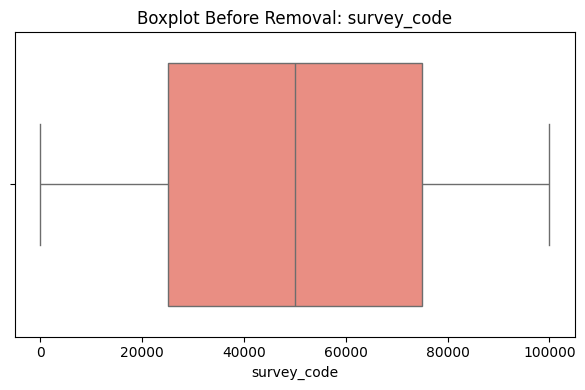

survey_code: Removed 0 outliers


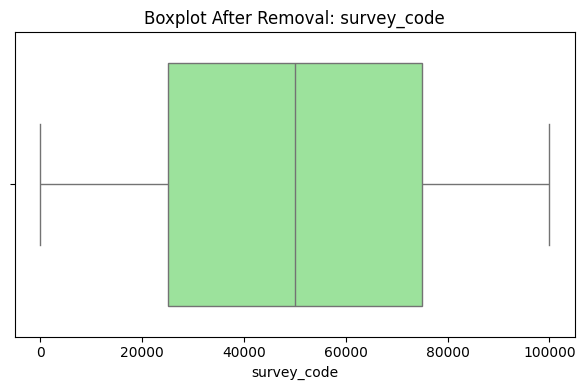

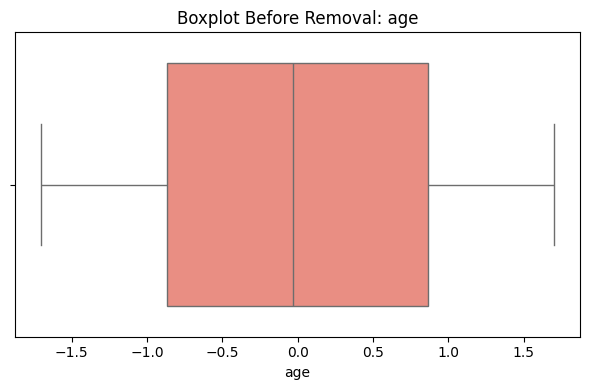

age: Removed 0 outliers


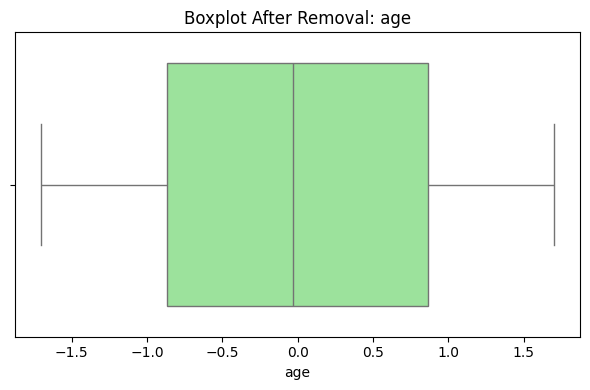

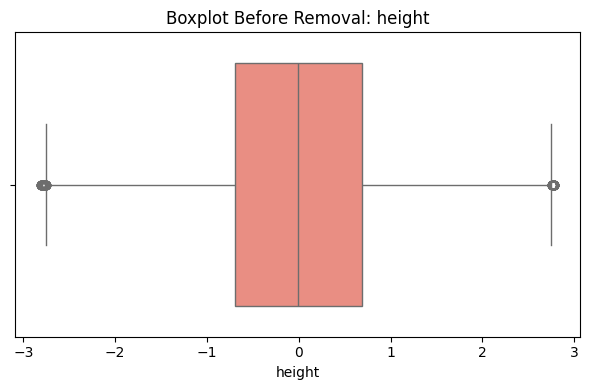

height: Removed 80 outliers


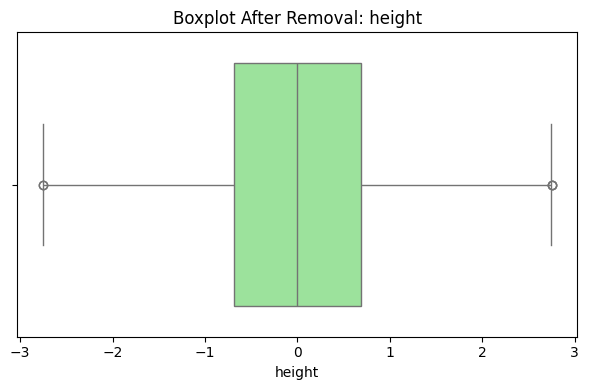

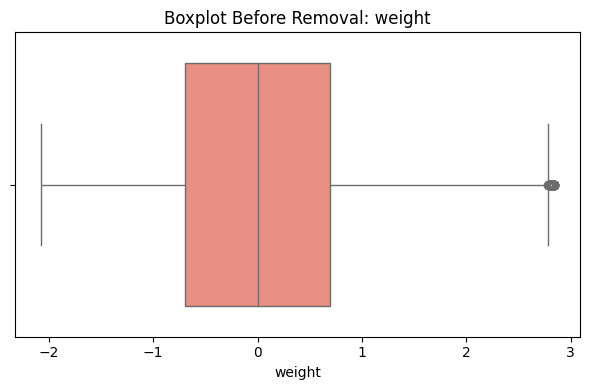

weight: Removed 49 outliers


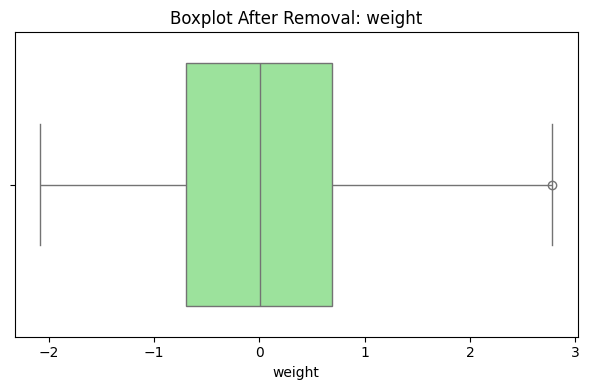

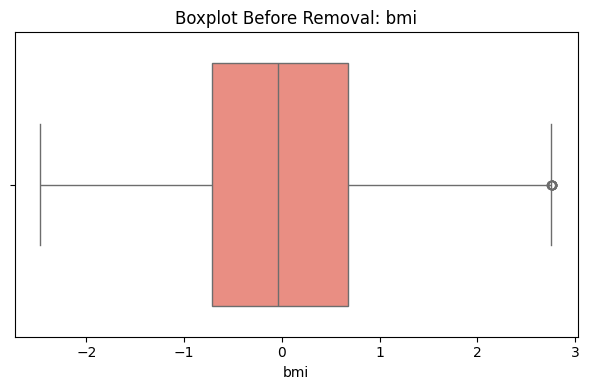

bmi: Removed 8 outliers


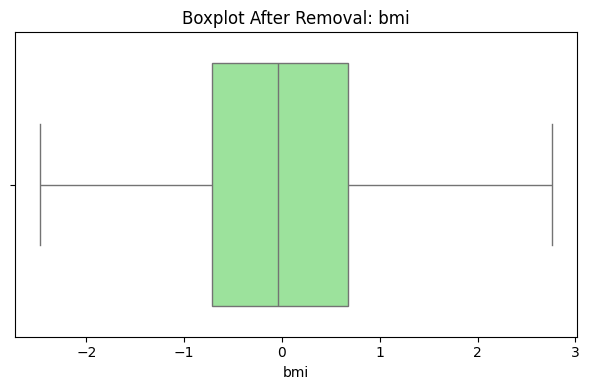

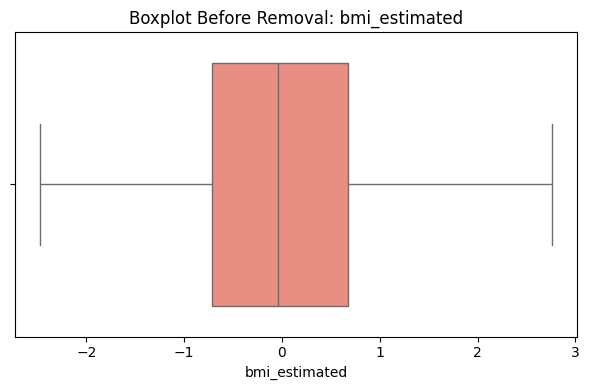

bmi_estimated: Removed 0 outliers


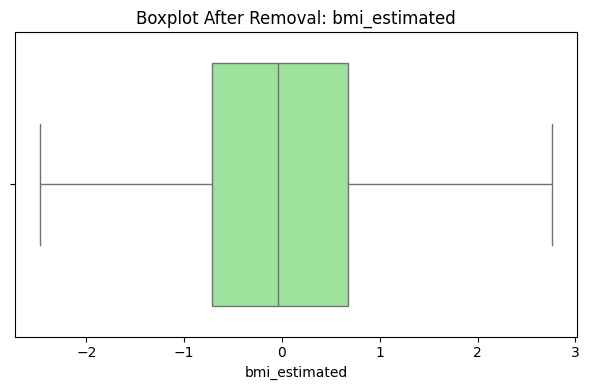

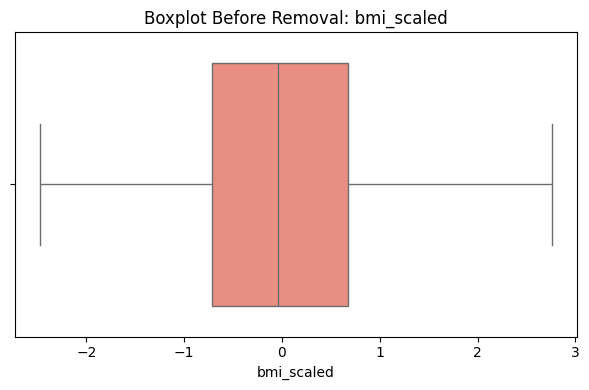

bmi_scaled: Removed 0 outliers


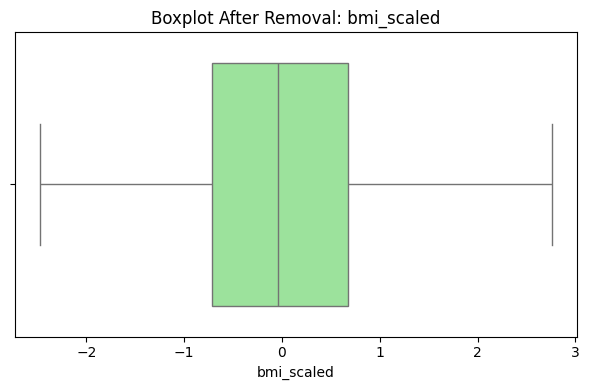

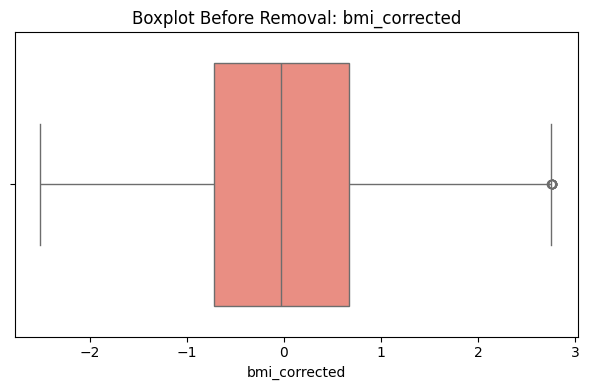

bmi_corrected: Removed 7 outliers


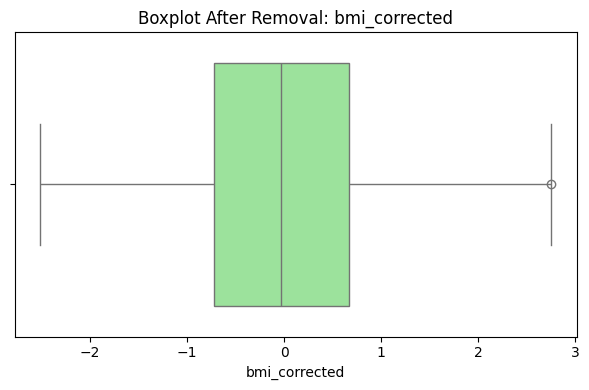

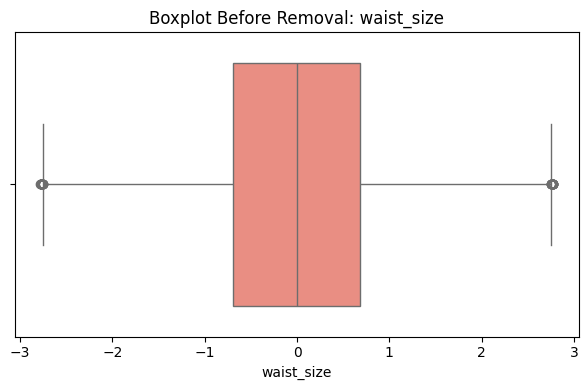

waist_size: Removed 51 outliers


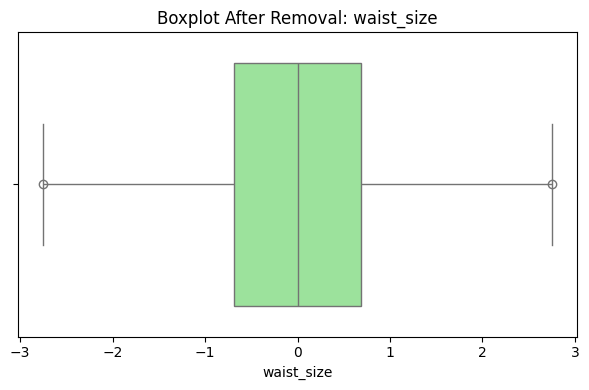

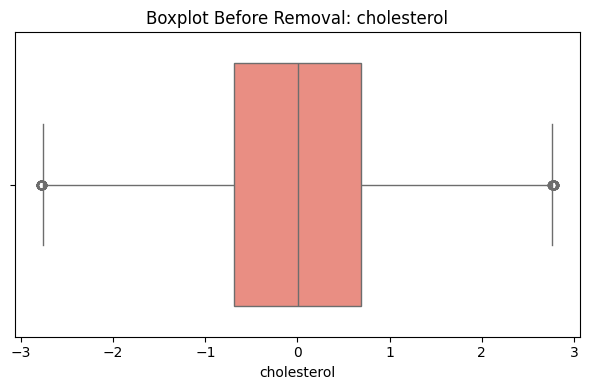

cholesterol: Removed 45 outliers


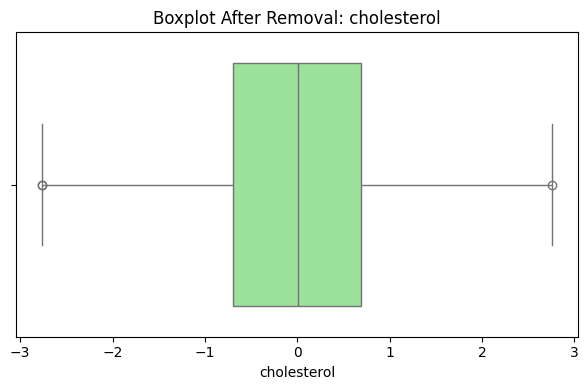

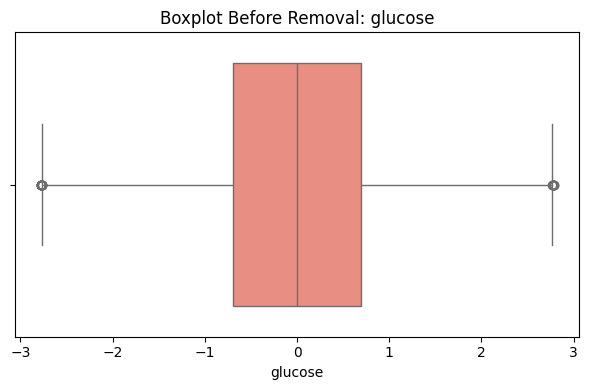

glucose: Removed 25 outliers


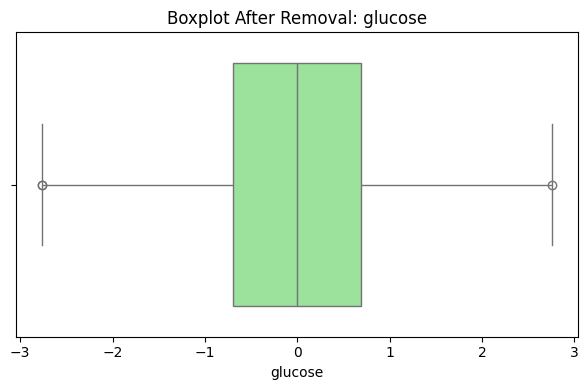

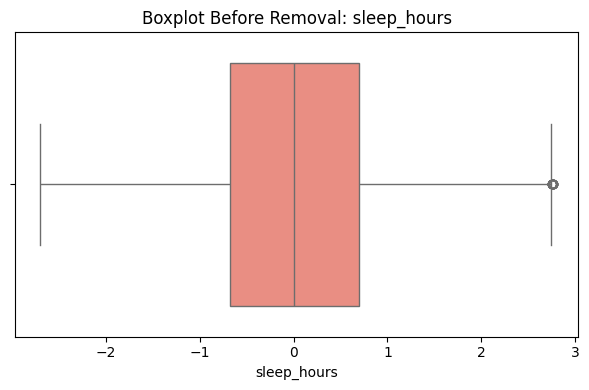

sleep_hours: Removed 16 outliers


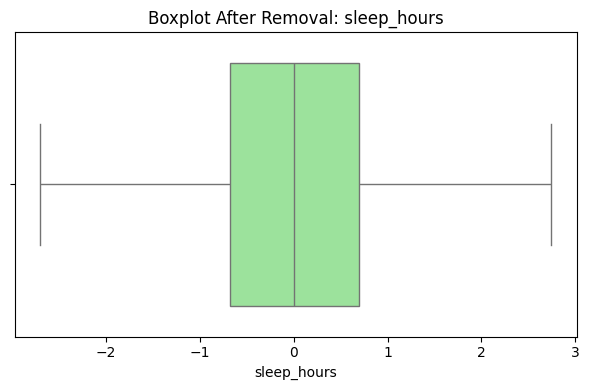

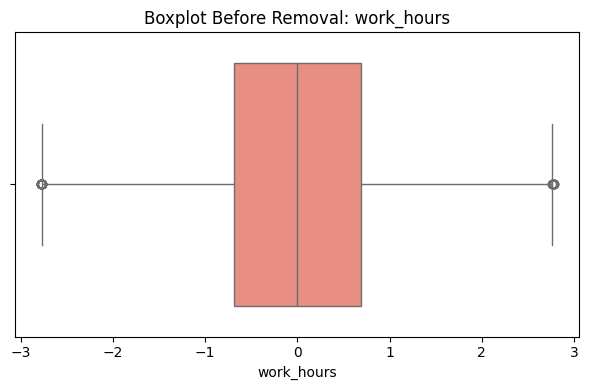

work_hours: Removed 34 outliers


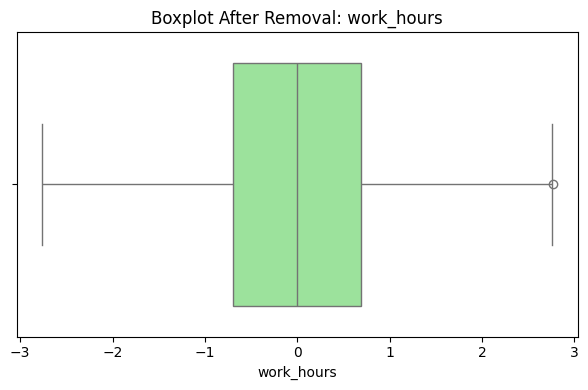

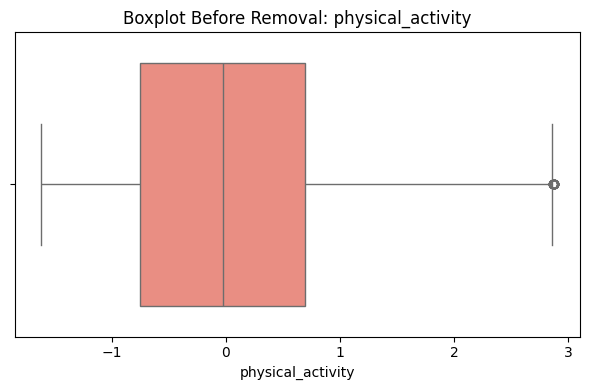

physical_activity: Removed 18 outliers


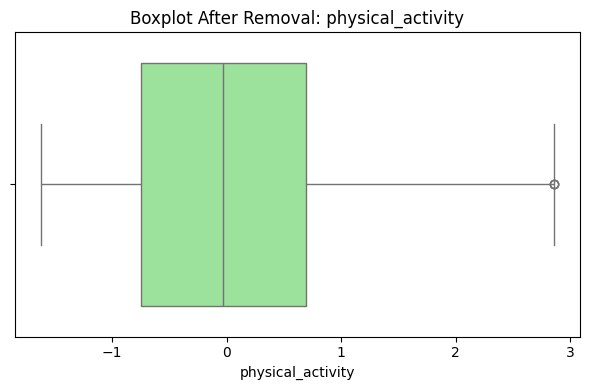

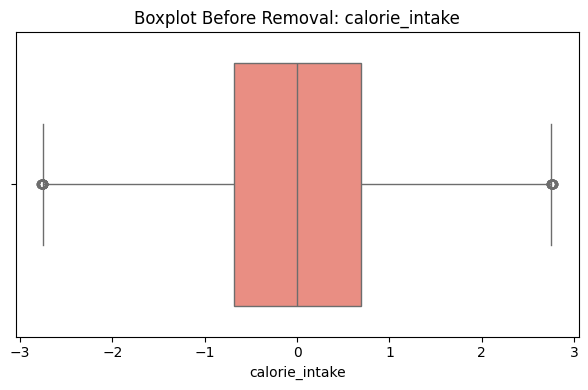

calorie_intake: Removed 41 outliers


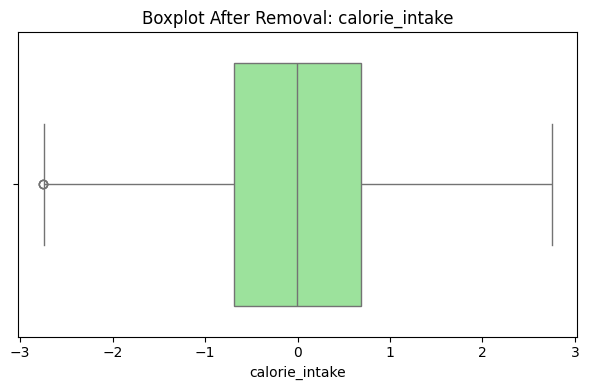

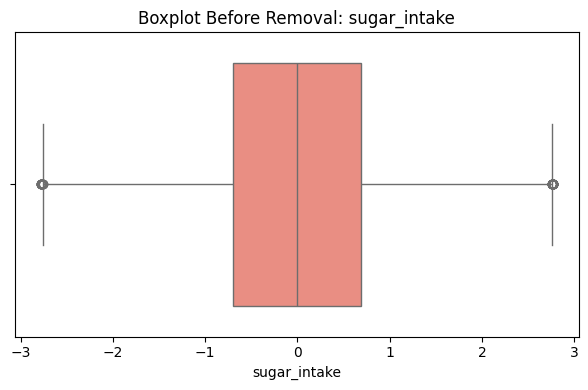

sugar_intake: Removed 45 outliers


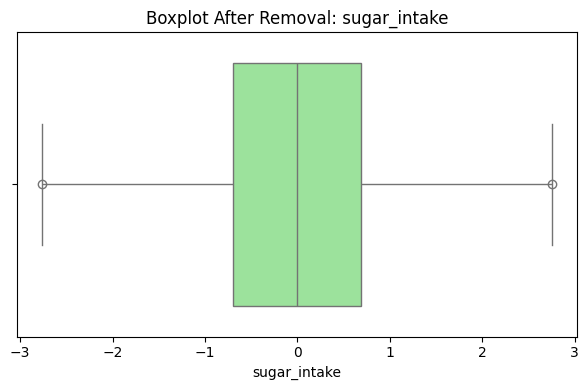

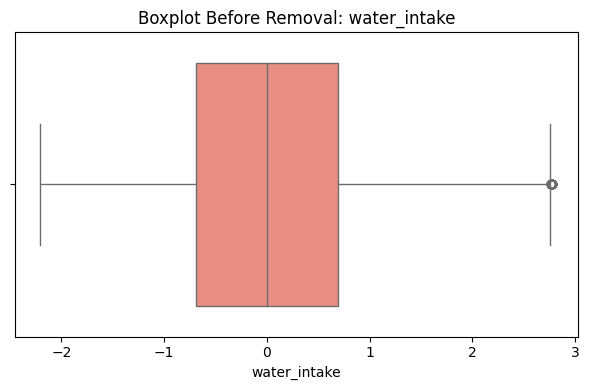

water_intake: Removed 30 outliers


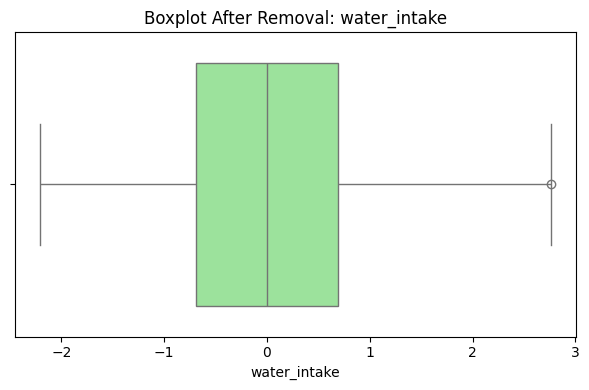

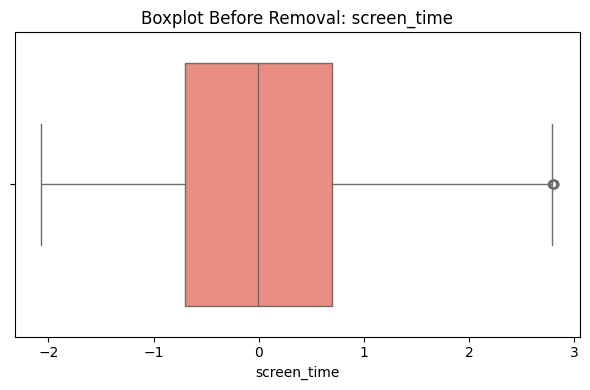

screen_time: Removed 8 outliers


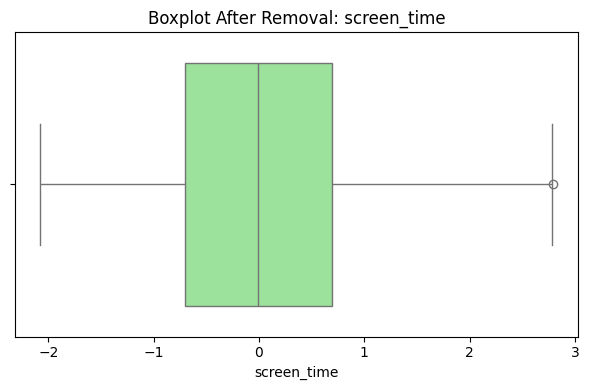

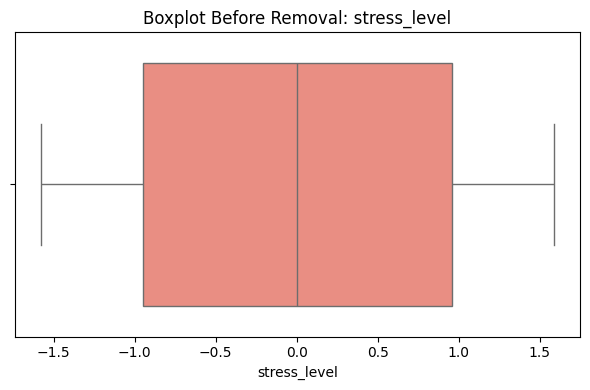

stress_level: Removed 0 outliers


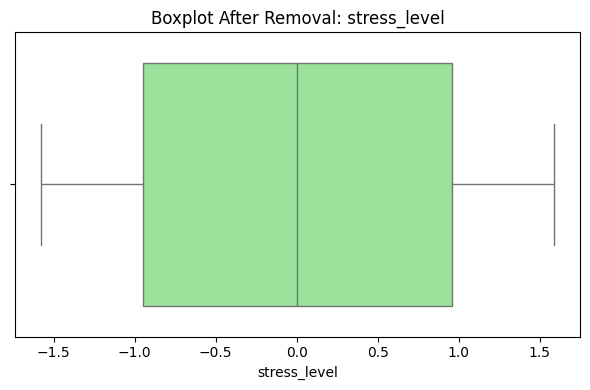

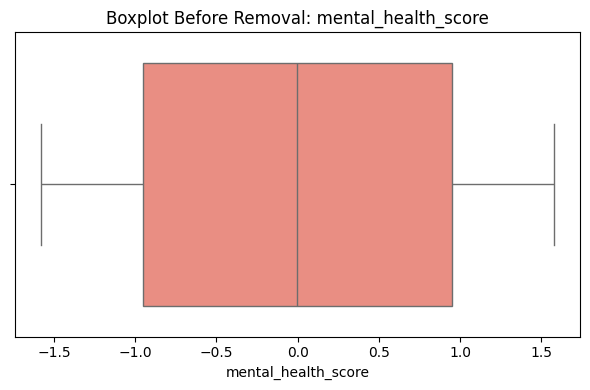

mental_health_score: Removed 0 outliers


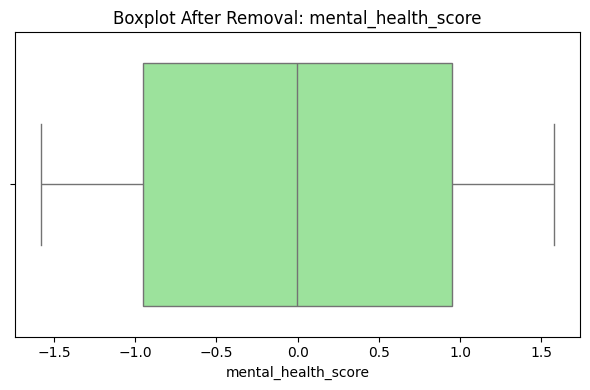

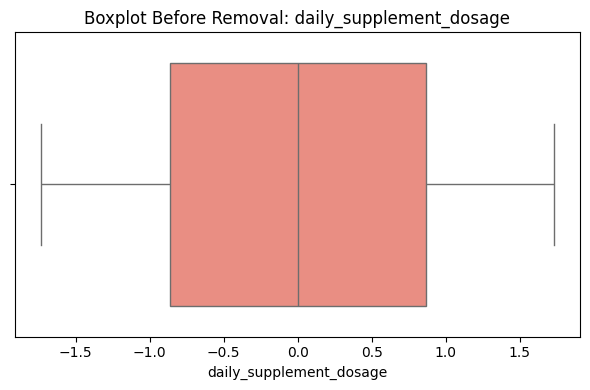

daily_supplement_dosage: Removed 0 outliers


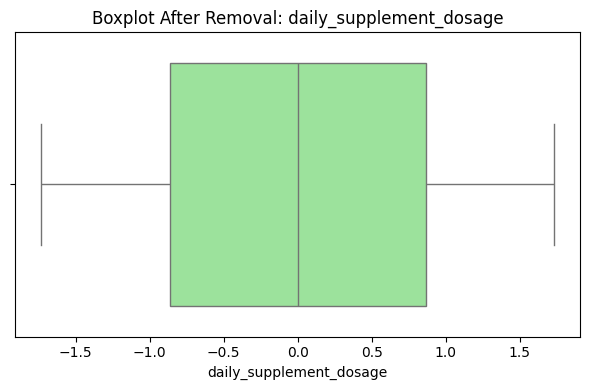

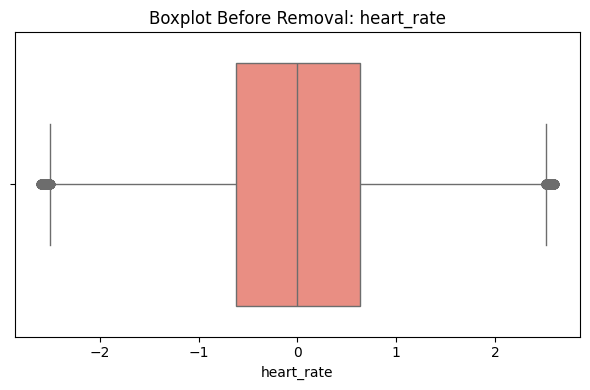

heart_rate: Removed 425 outliers


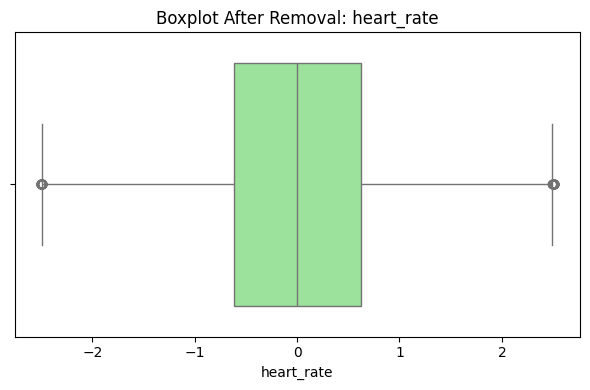

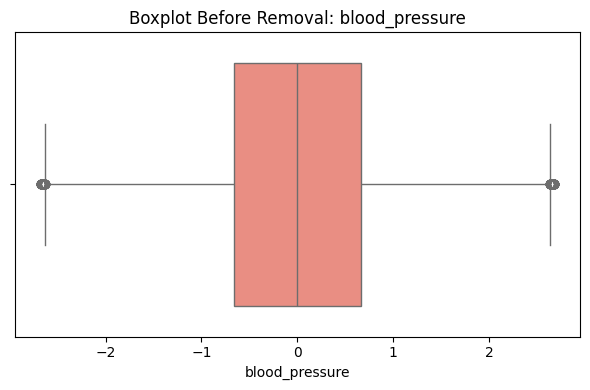

blood_pressure: Removed 161 outliers


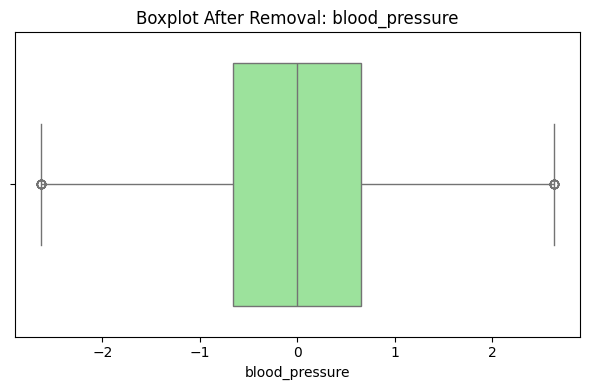

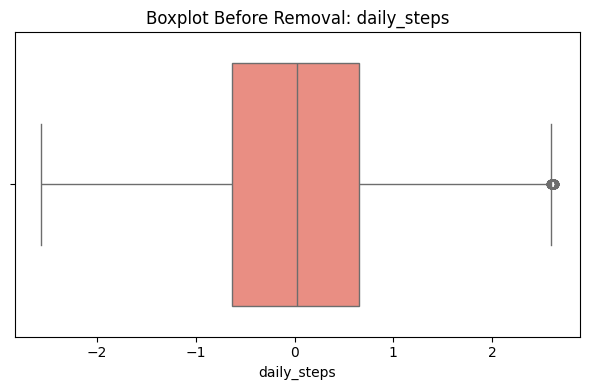

daily_steps: Removed 60 outliers


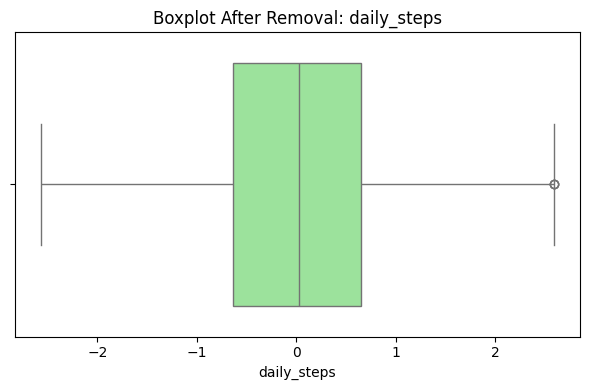

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define the IQR-based outlier removal function with box plots
def remove_outliers_iqr(df, column):
    # 📦 Boxplot before removal
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column], color='salmon')
    plt.title(f'Boxplot Before Removal: {column}')
    plt.tight_layout()
    plt.show()

    # ✂️ IQR filtering
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    removed = df.shape[0] - filtered_df.shape[0]
    print(f"{column}: Removed {removed} outliers")

    # 📦 Boxplot after removal
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=filtered_df[column], color='lightgreen')
    plt.title(f'Boxplot After Removal: {column}')
    plt.tight_layout()
    plt.show()

    return filtered_df

# Step 2: Define target columns for outlier removal
outlier_cols = [
    'survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled',
    'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours',
    'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level',
    'mental_health_score', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps'
]

# Step 3: Apply outlier removal iteratively
for col in outlier_cols:
    if col in df.columns:
        df = remove_outliers_iqr(df, col)
    else:
        print(f"⚠️ Column '{col}' not found in DataFrame")

In [75]:
#4- Feature Scale and Normalize - IT24100418

In [43]:
# Select numeric columns (excluding binary/categorical)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns for scaling:", numeric_cols)

Numeric columns for scaling: ['survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day', 'electrolyte_level', 'environmental_risk_score', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded', 'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded', 'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded', 'family_history_encoded', 'pet_owner_encoded', 'target_encoded']


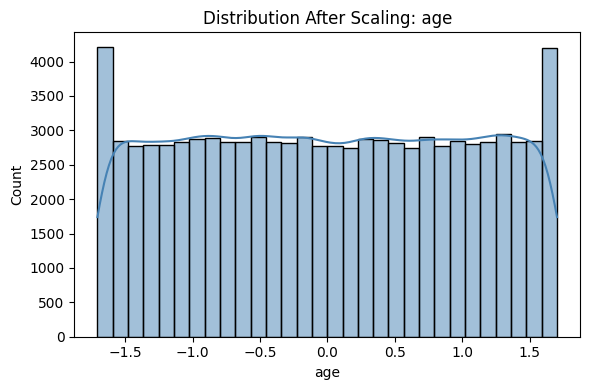

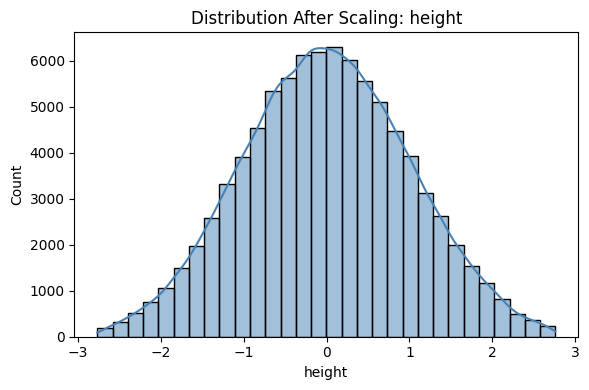

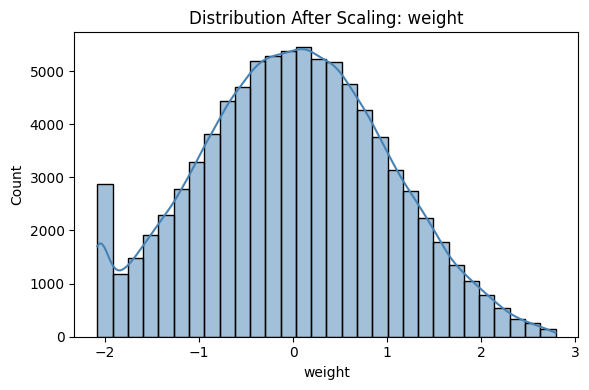

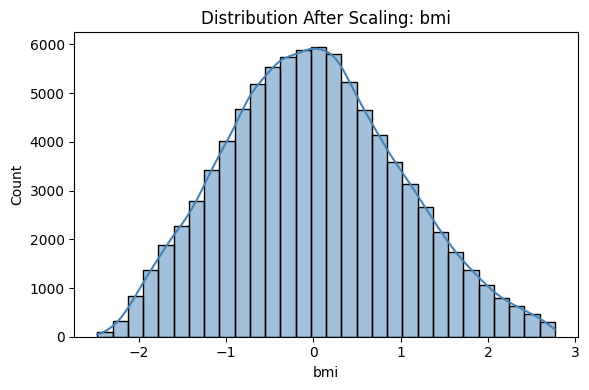

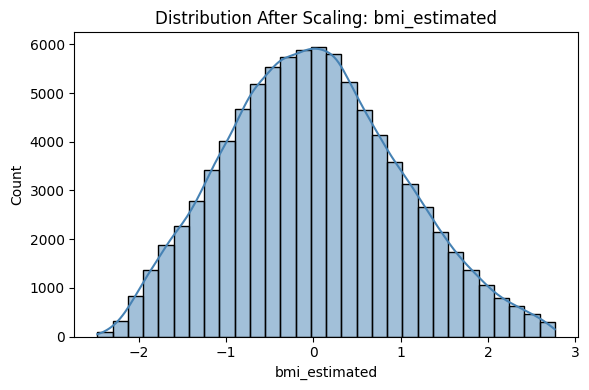

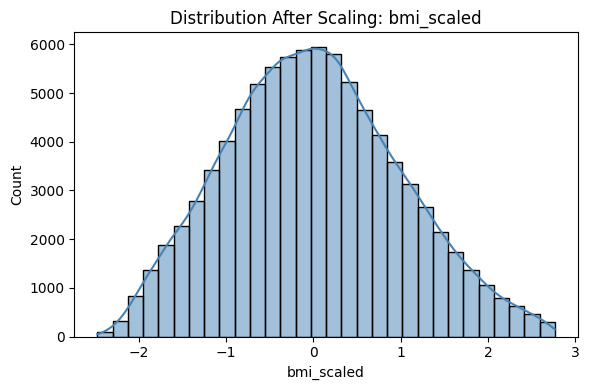

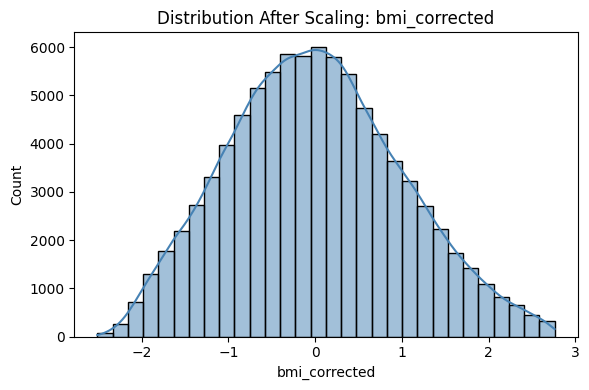

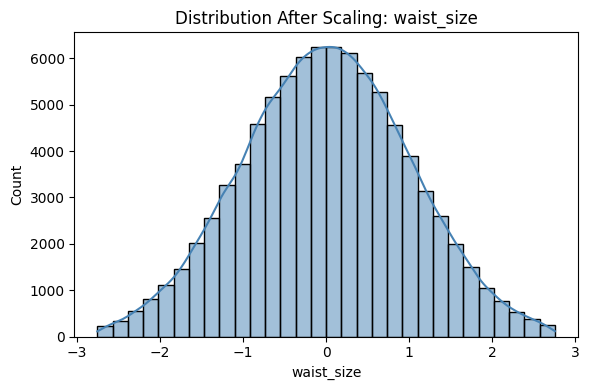

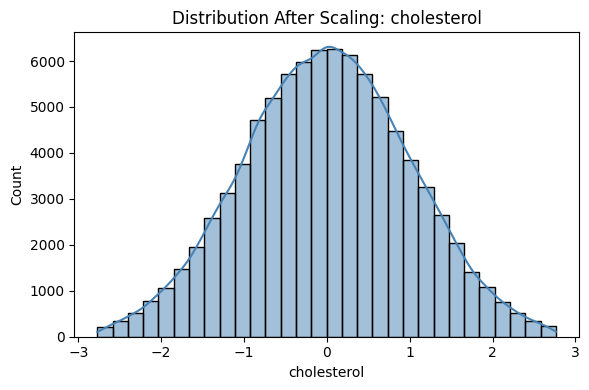

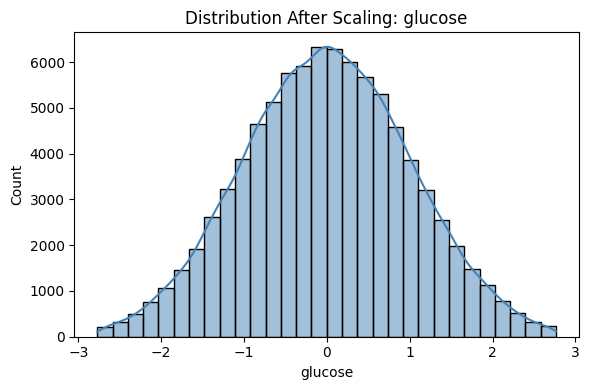

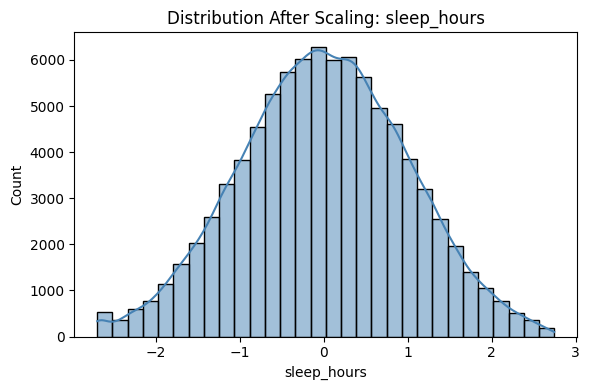

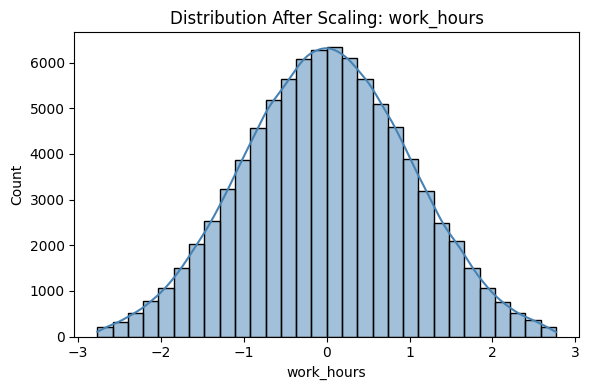

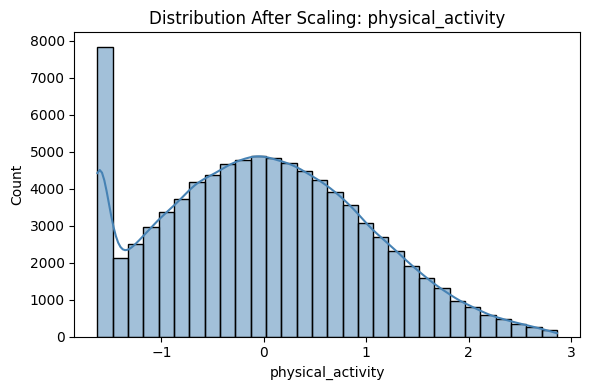

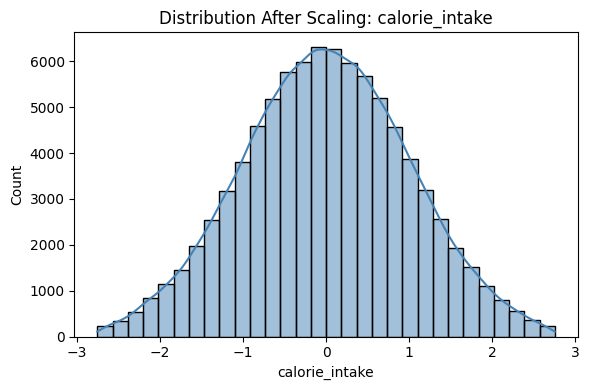

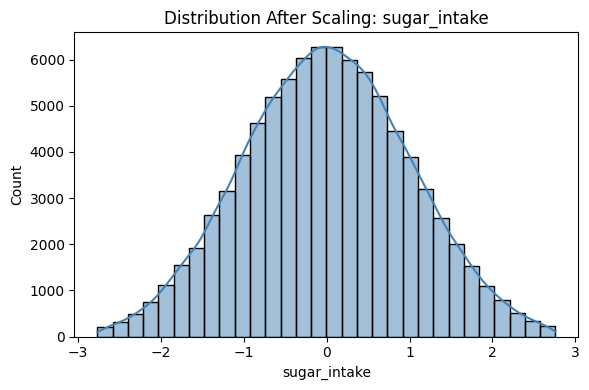

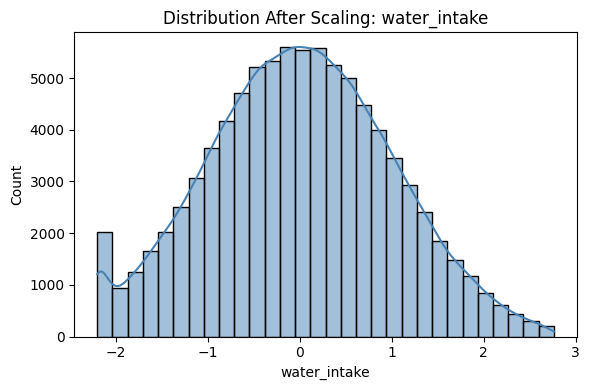

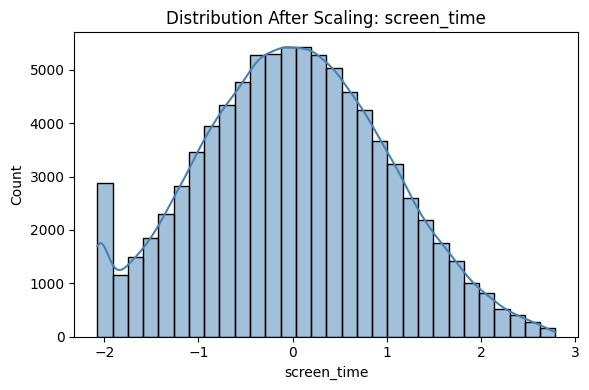

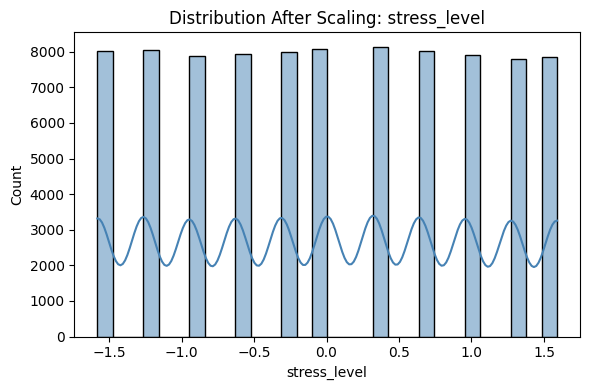

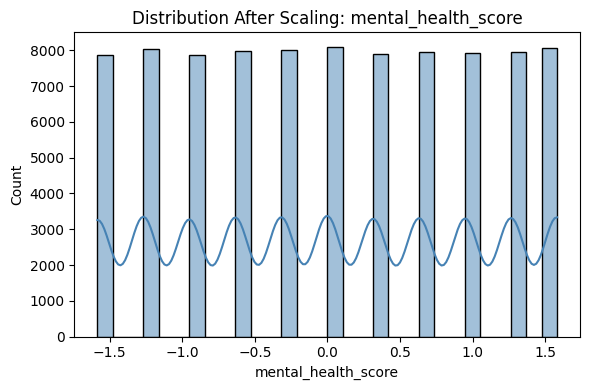

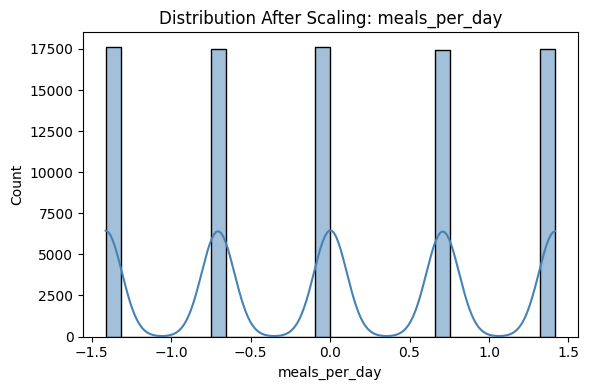

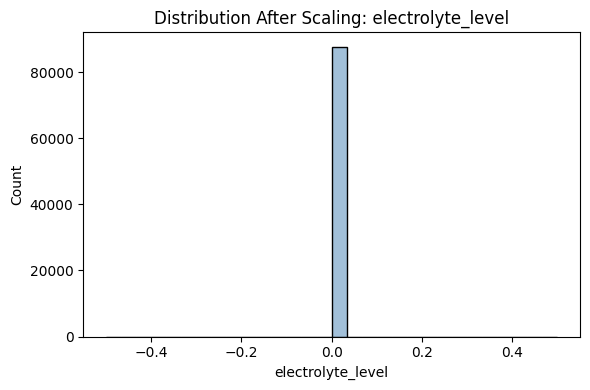

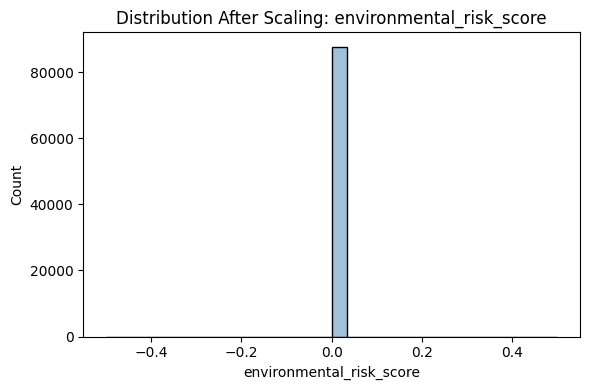

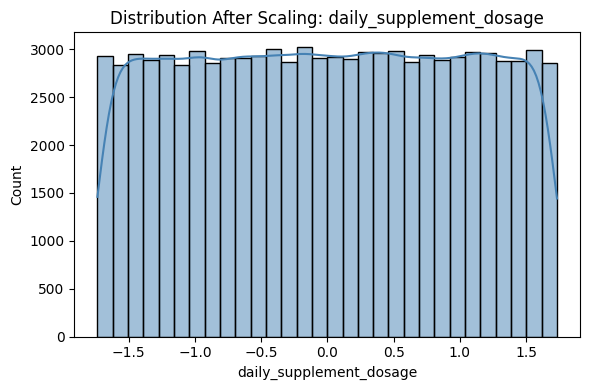

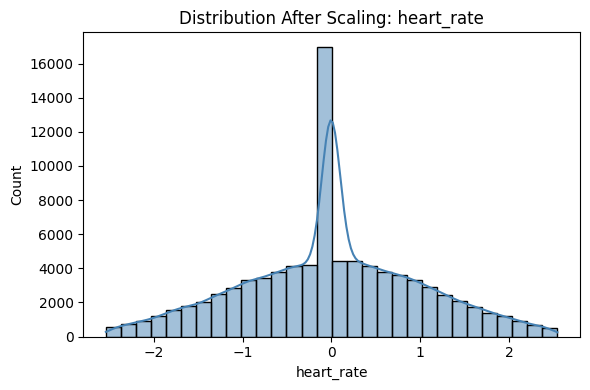

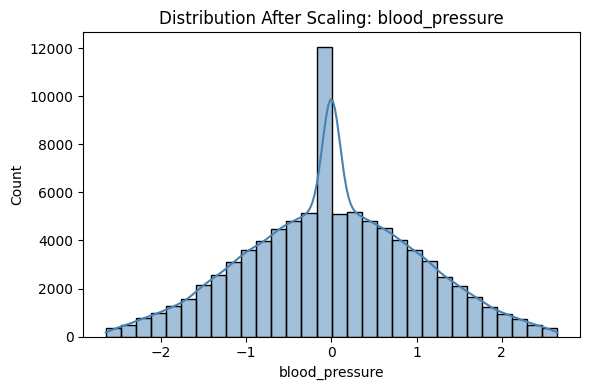

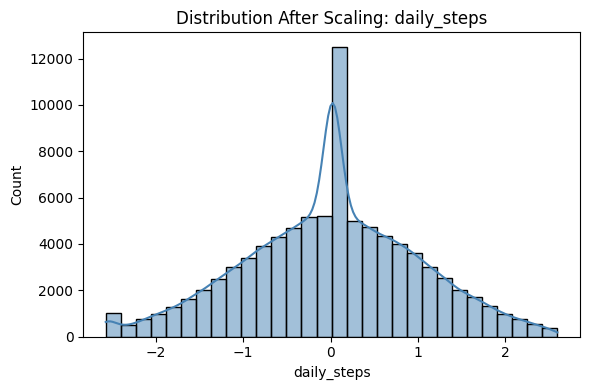

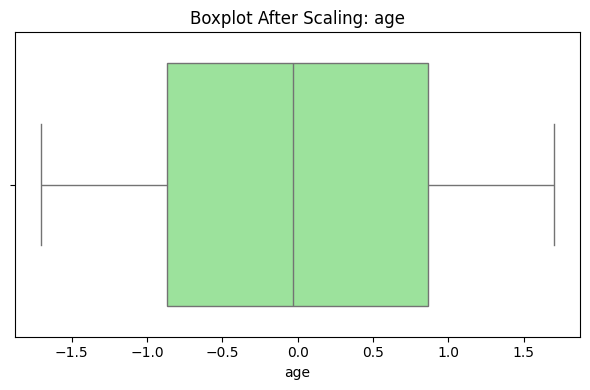

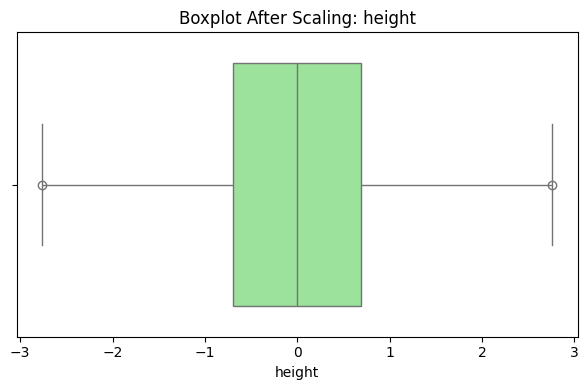

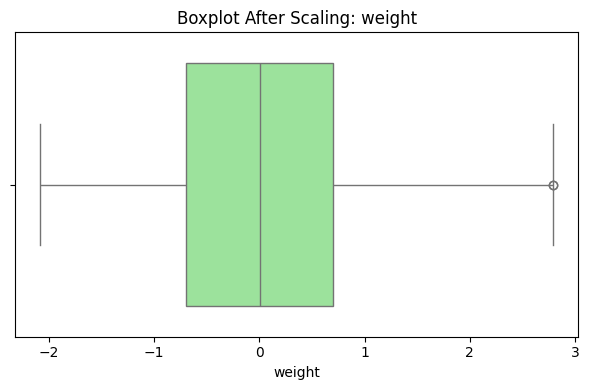

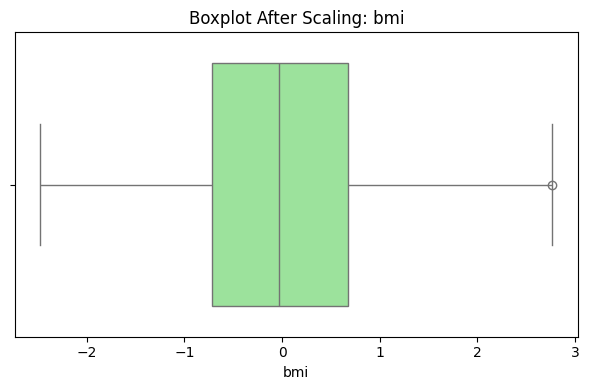

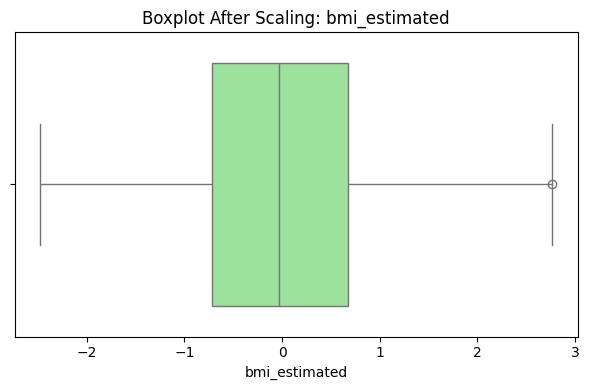

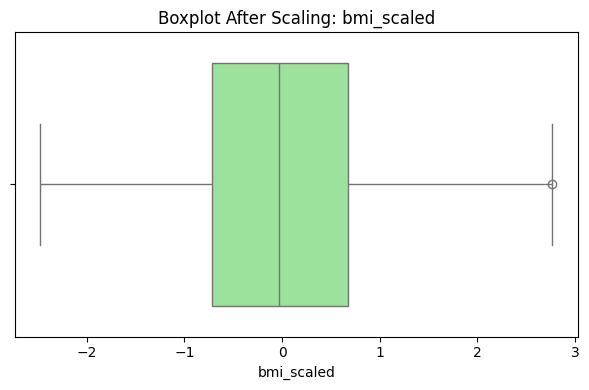

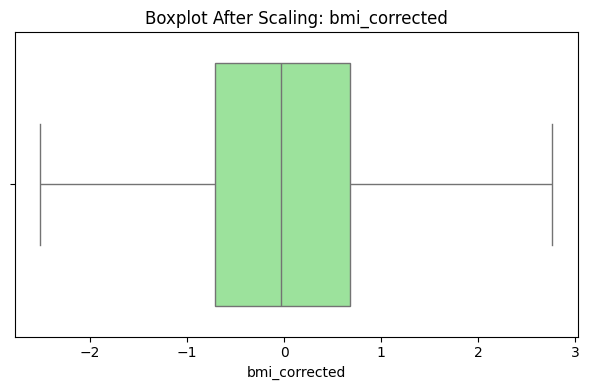

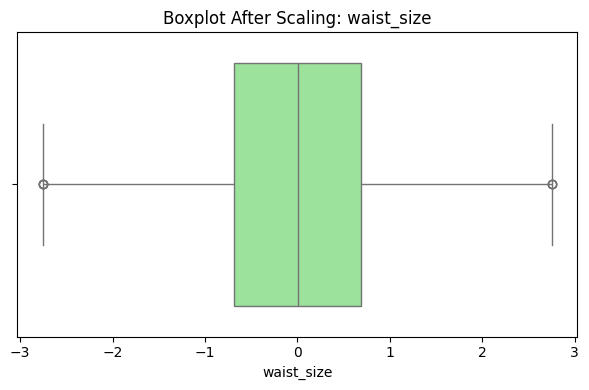

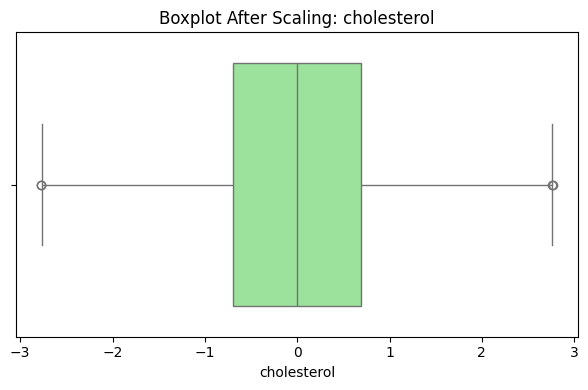

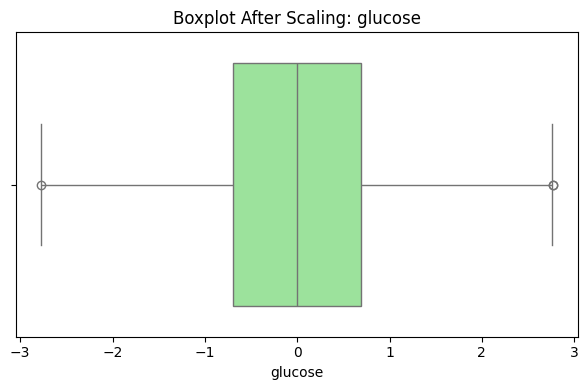

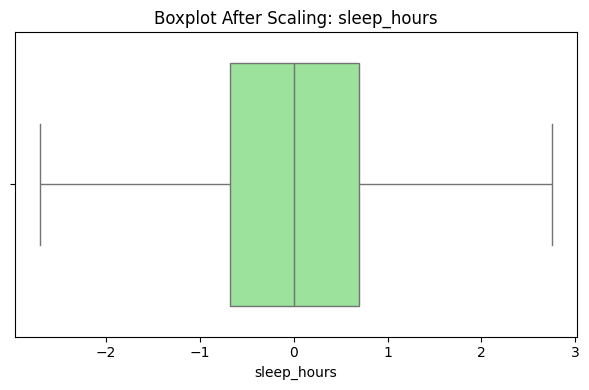

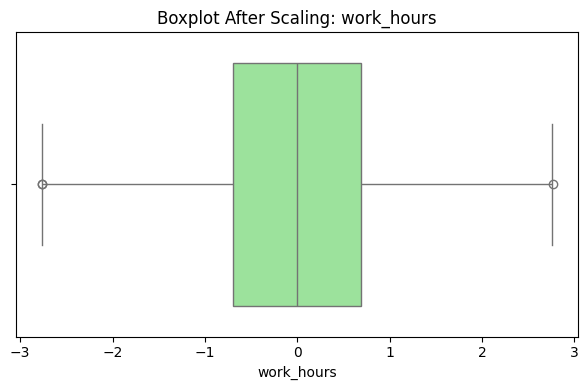

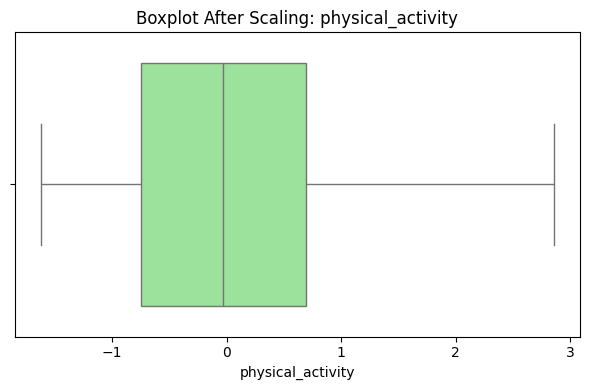

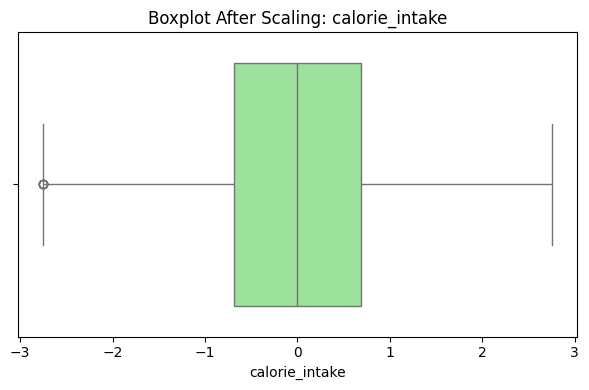

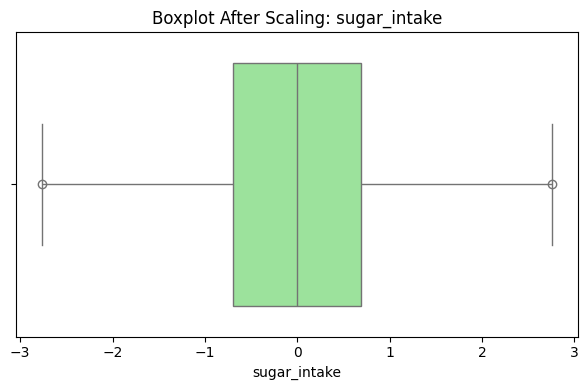

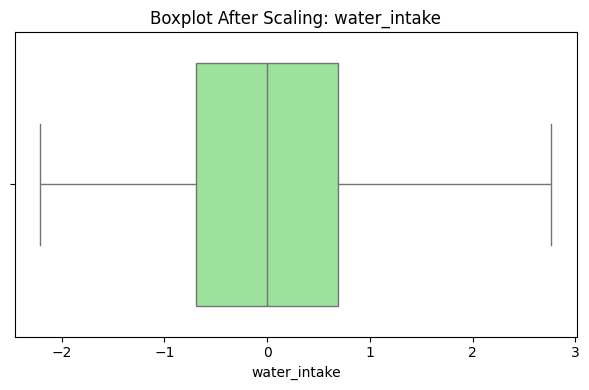

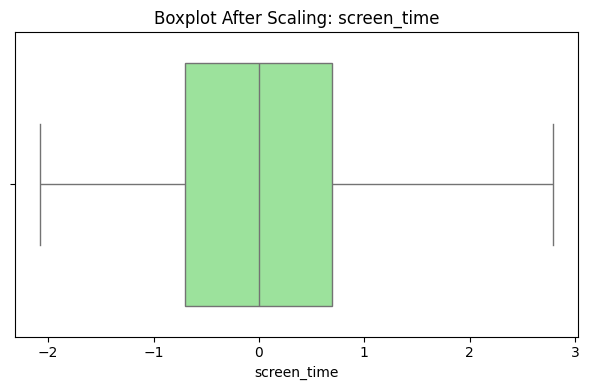

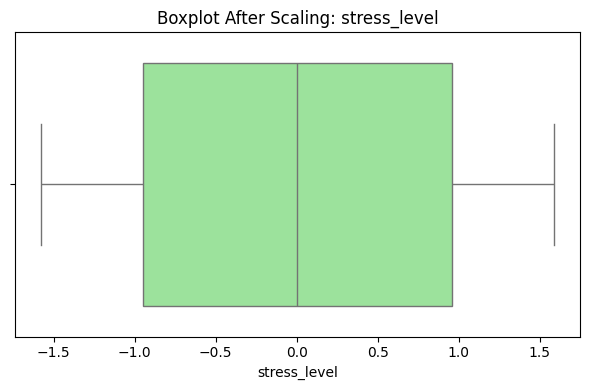

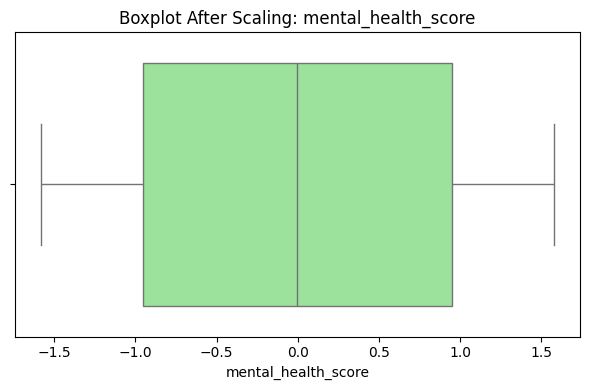

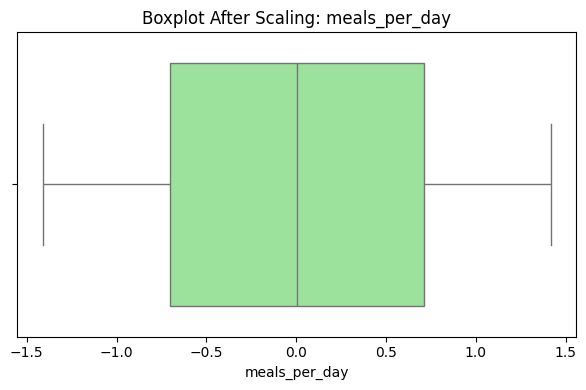

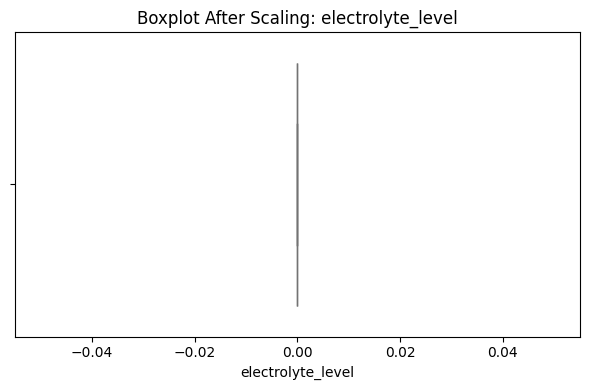

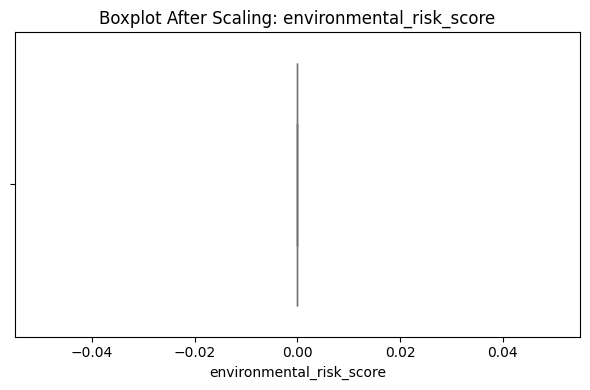

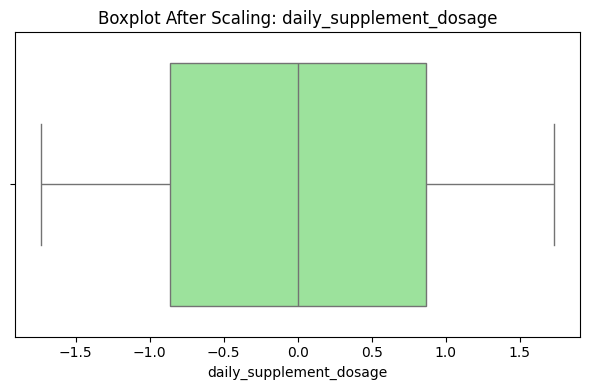

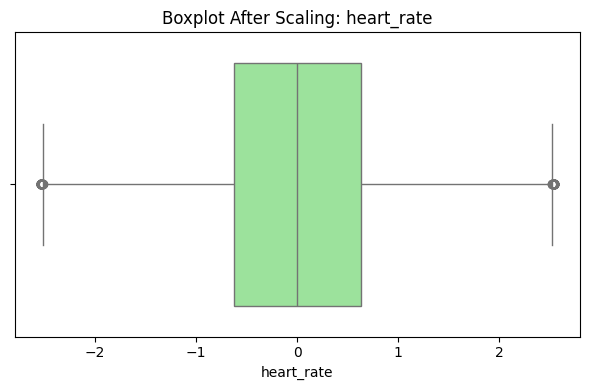

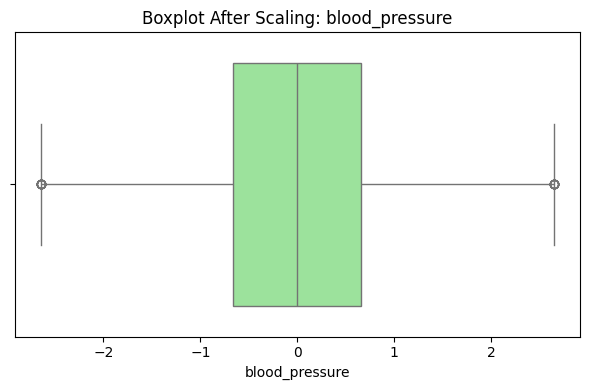

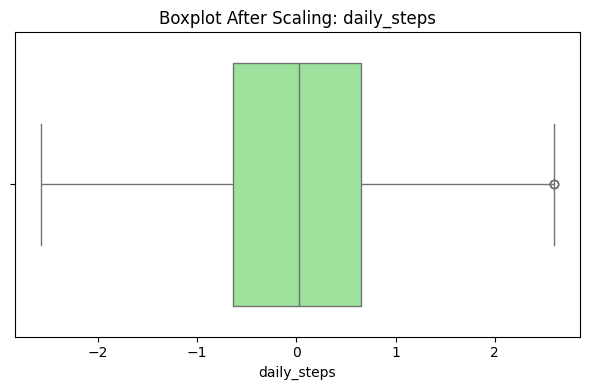

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12964\1048128794.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


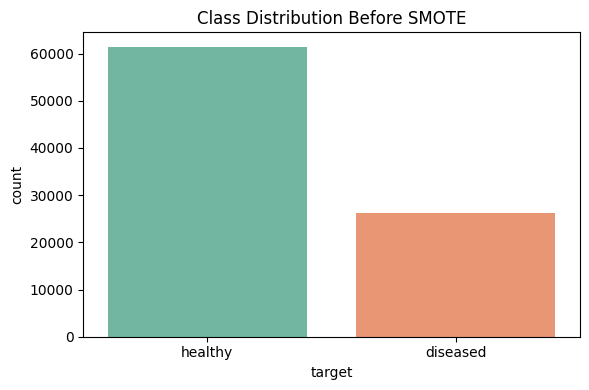

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12964\1048128794.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='Set1')


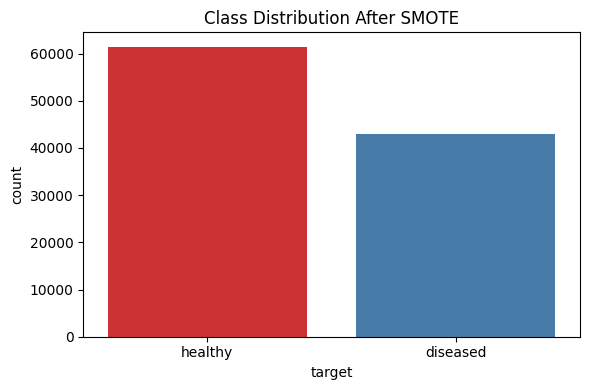

Scaled columns:
                age        height        weight           bmi  bmi_estimated  \
count  8.765200e+04  8.765200e+04  8.765200e+04  8.765200e+04   8.765200e+04   
mean  -3.453329e-17 -2.407603e-17 -6.322997e-18 -3.080434e-18  -3.080434e-18   
std    1.000006e+00  1.000006e+00  1.000006e+00  1.000006e+00   1.000006e+00   
min   -1.706648e+00 -2.762969e+00 -2.081288e+00 -2.474059e+00  -2.474059e+00   
25%   -8.679725e-01 -6.920946e-01 -6.969059e-01 -7.189057e-01  -7.189057e-01   
50%   -2.929731e-02 -4.942499e-03  5.467020e-03 -3.417287e-02  -3.417287e-02   
75%    8.652896e-01  6.879079e-01  6.968610e-01  6.742459e-01   6.742459e-01   
max    1.703965e+00  2.758292e+00  2.788773e+00  2.764146e+00   2.764146e+00   

         bmi_scaled  bmi_corrected    waist_size   cholesterol       glucose  \
count  8.765200e+04   8.765200e+04  8.765200e+04  8.765200e+04  8.765200e+04   
mean  -1.242307e-17  -5.228632e-18 -2.261687e-17  2.512986e-18  1.629388e-17   
std    1.000006e+00   1

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ✅ Step 1: Define the columns to scale
scale_cols = [
    'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected',
    'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours',
    'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake',
    'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day',
    'electrolyte_level', 'environmental_risk_score', 'daily_supplement_dosage',
    'heart_rate', 'blood_pressure', 'daily_steps'
]

# ✅ Step 2: Keep only the columns that exist in the current DataFrame
existing_cols = [col for col in scale_cols if col in df.columns]

# ✅ Step 3: Apply StandardScaler to normalize selected columns
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[existing_cols] = scaler.fit_transform(df[existing_cols])

# 📊 Step 3.5: Visualize scaled distributions
for col in existing_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_scaled[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution After Scaling: {col}')
    plt.tight_layout()
    plt.show()

# 📦 Step 3.6: Box plots to inspect outliers
for col in existing_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_scaled[col], color='lightgreen')
    plt.title(f'Boxplot After Scaling: {col}')
    plt.tight_layout()
    plt.show()

# ✅ Step 4: Define feature matrix and target vector
X_scaled = df_scaled[existing_cols]
y = df['target']  # Replace 'target' with your actual label column name

# 📈 Step 4.5: Visualize class imbalance before SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title("Class Distribution Before SMOTE")
plt.tight_layout()
plt.show()

# ✅ Step 5: Apply SMOTE to reduce class imbalance
smote = SMOTE(random_state=24, sampling_strategy=0.7)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 📈 Step 5.5: Visualize class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, palette='Set1')
plt.title("Class Distribution After SMOTE")
plt.tight_layout()
plt.show()

# ✅ Step 6: Confirm scaling results with summary statistics
print("Scaled columns:")
print(df_scaled[existing_cols].describe())

In [47]:
df = df_scaled
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,occupation_Engineer,occupation_Farmer,occupation_Teacher,device_usage_encoded,healthcare_access_encoded,insurance_encoded,sunlight_exposure_encoded,family_history_encoded,pet_owner_encoded,target_encoded
1,2,1.145111,Female,-0.724865,1.970790,2.215676,2.215676,2.215676,2.177921,0.055271,...,True,False,False,1.0,1.0,0,2.0,1,0,1
2,3,-0.141072,Male,0.742255,0.771800,0.248481,0.248481,0.248481,0.233058,0.456999,...,False,False,True,2.0,2.0,1,2.0,0,0,1
3,4,-0.923966,Female,0.202223,-0.457485,-0.527224,-0.527224,-0.527224,-0.552138,1.330334,...,False,False,True,0.0,1.0,0,2.0,0,1,1
4,5,0.641822,Female,-0.683019,-2.079012,-1.662872,-1.662872,-1.662872,-1.679607,-1.362857,...,False,False,False,0.0,1.0,1,2.0,1,1,1
6,7,1.648400,Female,-0.416593,-0.324896,-0.128938,-0.128938,-0.128938,-0.146991,-1.464036,...,True,False,False,1.0,0.0,1,2.0,0,0,1


In [84]:
#5- Feature Selection - IT24100390

In [48]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with variance below 0.01
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(df.select_dtypes(include=[np.number]))

# Get selected column names
selected_cols = df.select_dtypes(include=[np.number]).columns[selector.get_support()]
print("Selected by variance:", selected_cols.tolist())


Selected by variance: ['survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded', 'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded', 'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded', 'family_history_encoded', 'pet_owner_encoded', 'target_encoded']


In [80]:
desired_cols = [
    'age', 'height', 'weight', 'bmi', 'waist_size', 'glucose', 'sleep_hours',
    'physical_activity', 'water_intake', 'meals_per_day', 'heart_rate',
    'blood_pressure', 'daily_steps', 'gender_encoded', 'family_history_encoded',
    'target_encoded'
]

# Your full variance-filtered list
variance_selected = [
    'survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled',
    'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours',
    'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
    'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
    'meals_per_day', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure',
    'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded',
    'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded',
    'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded',
    'family_history_encoded', 'pet_owner_encoded', 'target_encoded'
]

# Filter only the desired ones
selected_features = [col for col in desired_cols if col in variance_selected]
print("Final selected features:", selected_features)

df_selected = df[selected_features]

Final selected features: ['age', 'height', 'weight', 'bmi', 'waist_size', 'glucose', 'sleep_hours', 'physical_activity', 'water_intake', 'meals_per_day', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'family_history_encoded', 'target_encoded']


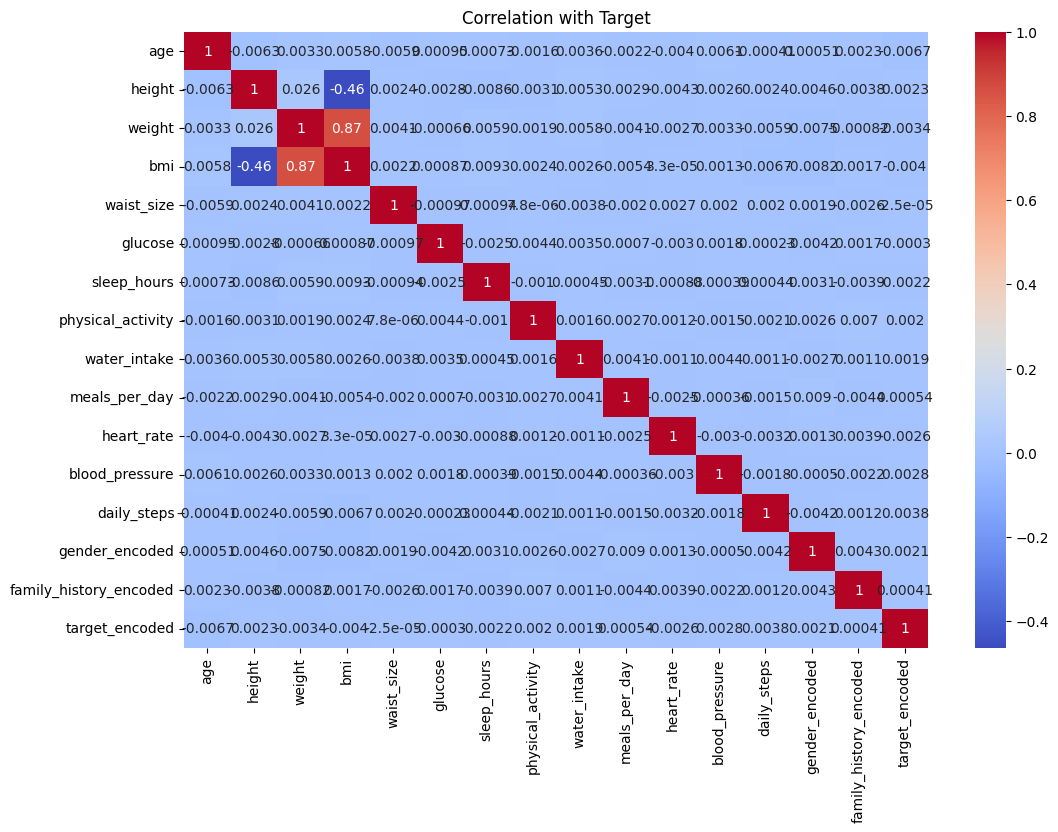

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove 'target_encoded' if it's already in selected_features
features_to_plot = [f for f in selected_features if f != 'target_encoded']

# Add 'target_encoded' back explicitly for correlation
features_to_plot.append('target_encoded')

plt.figure(figsize=(12, 8))
sns.heatmap(df[features_to_plot].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation with Target")
plt.show()

In [96]:
#6- Dimensionality Reduction - IT24100419

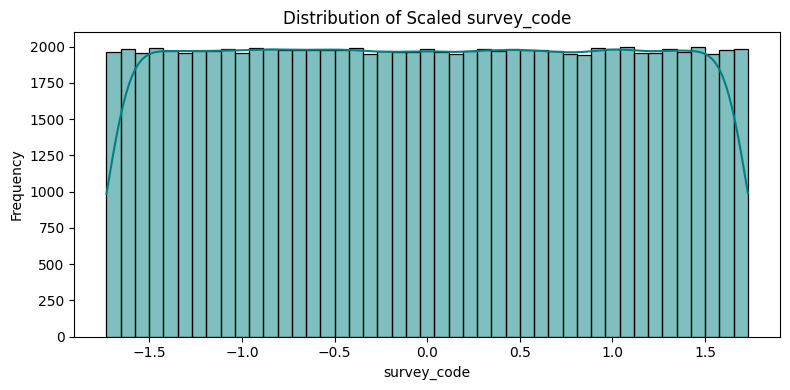

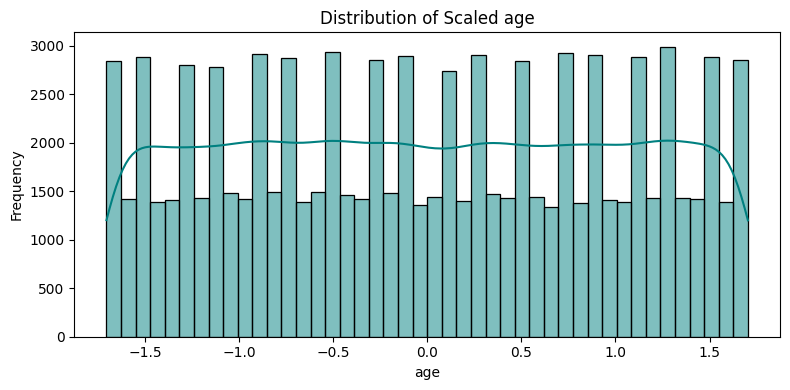

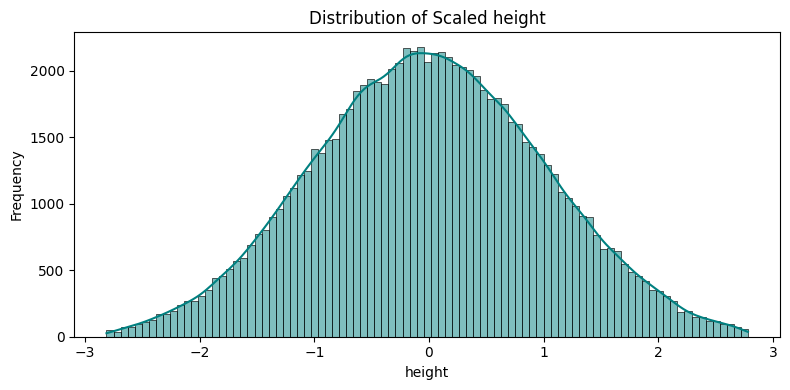

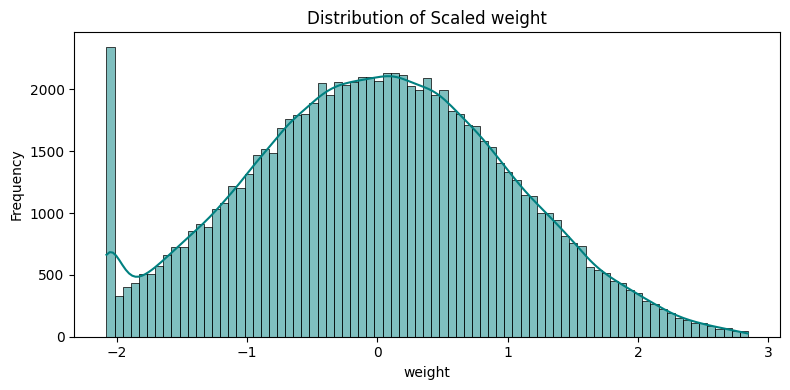

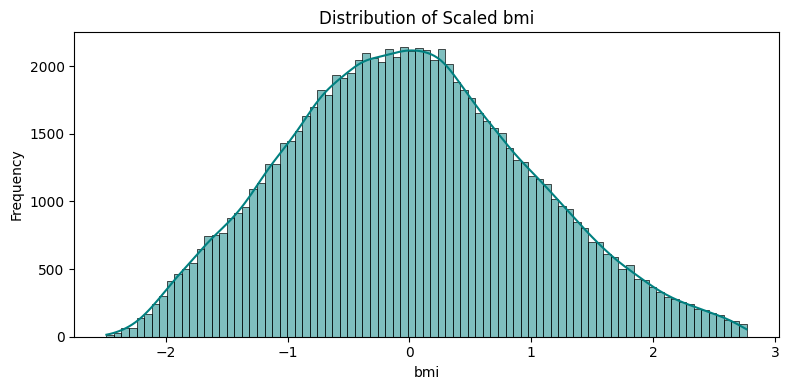

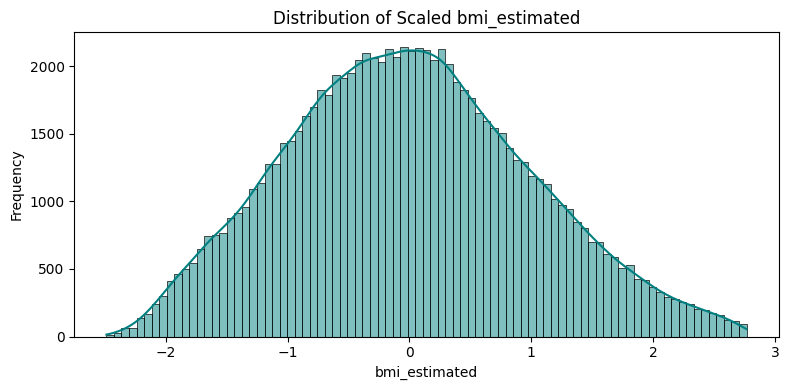

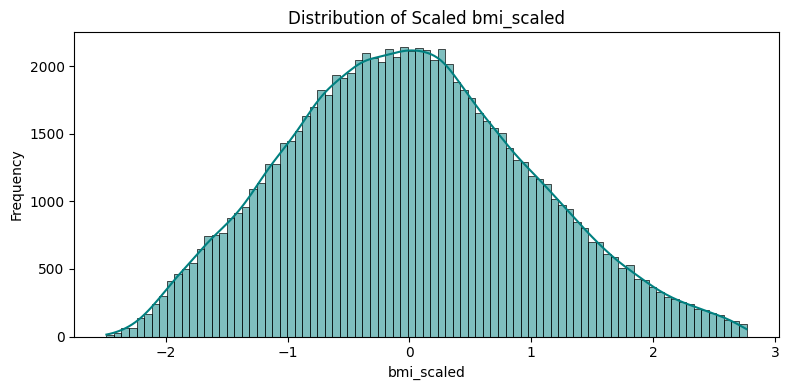

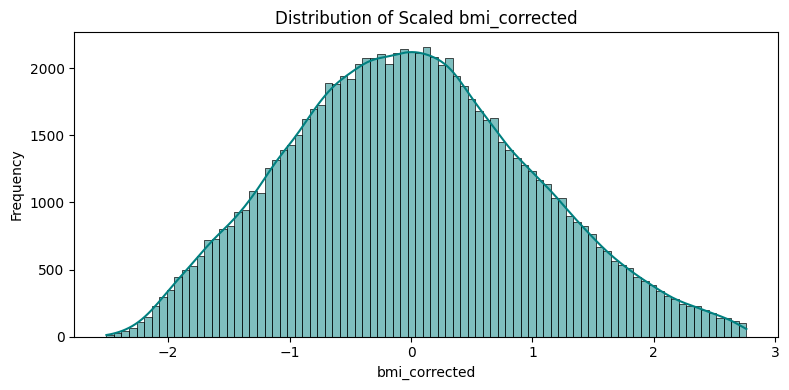

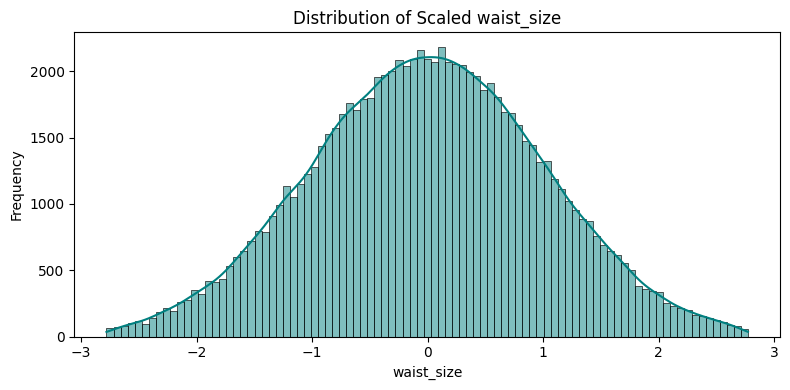

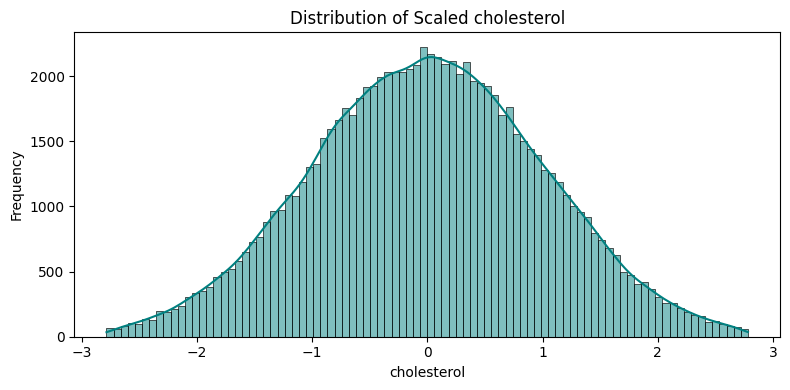

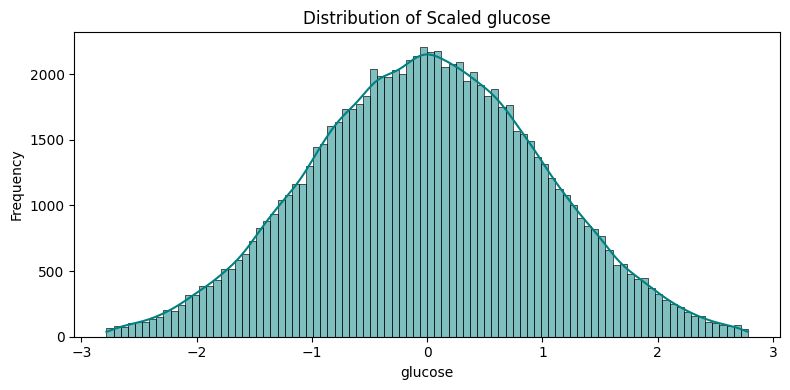

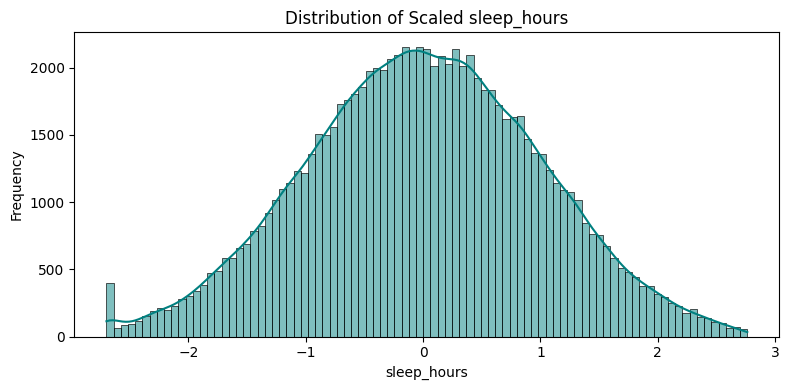

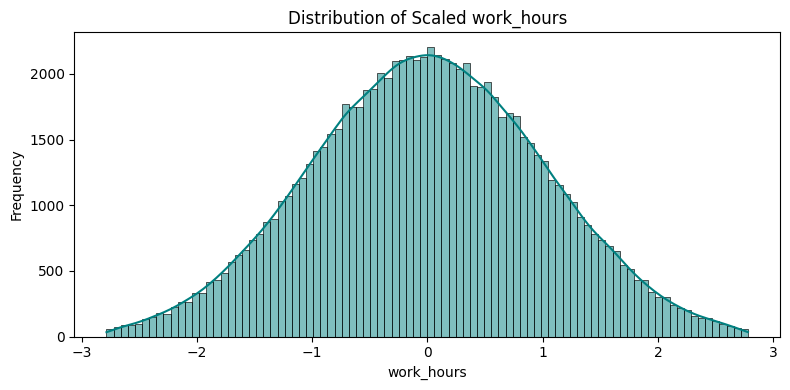

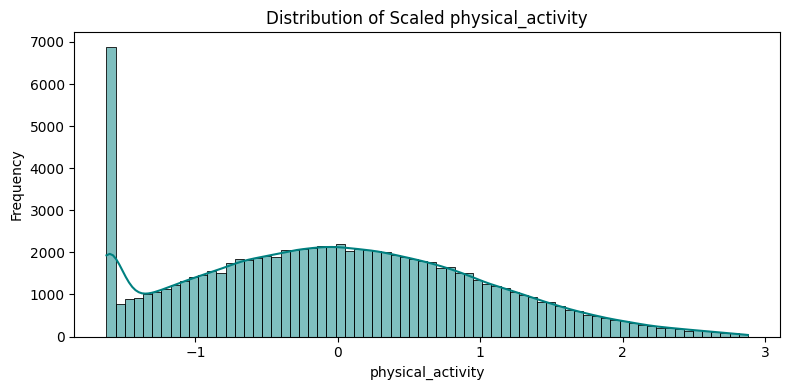

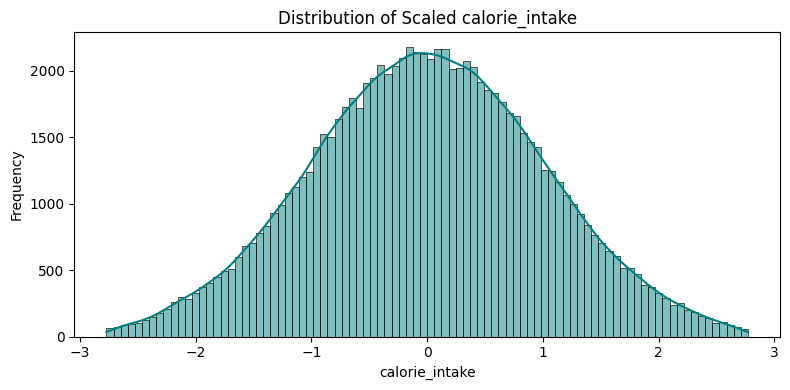

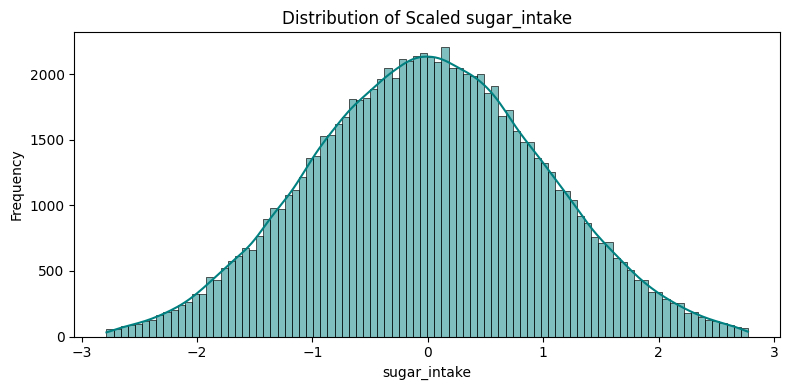

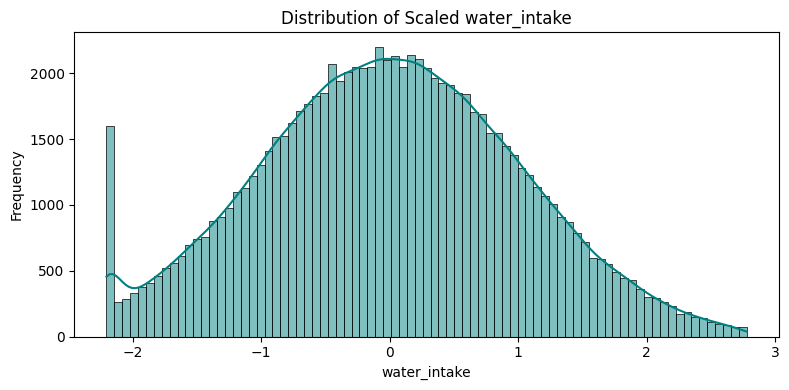

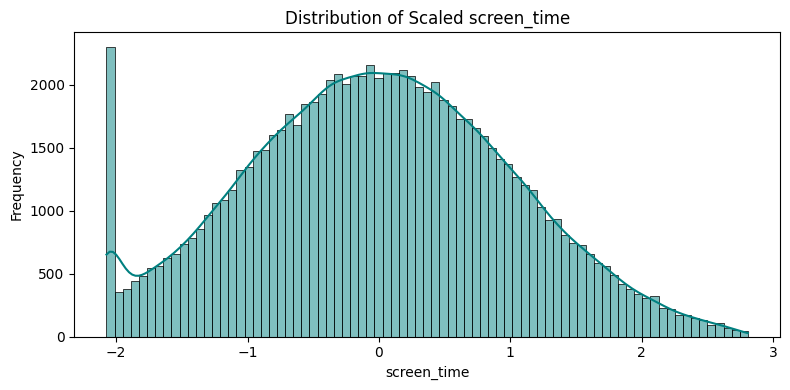

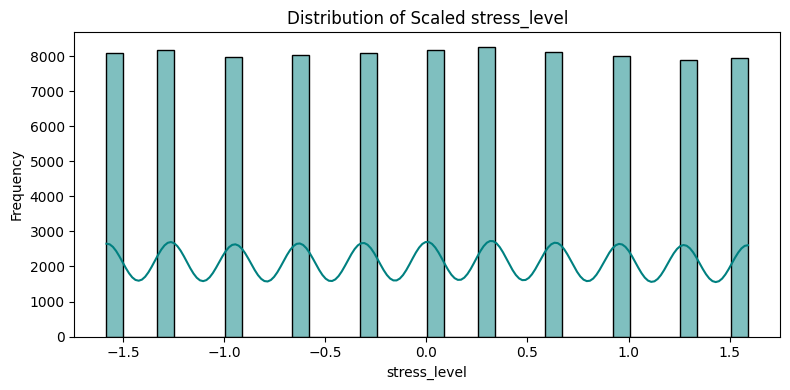

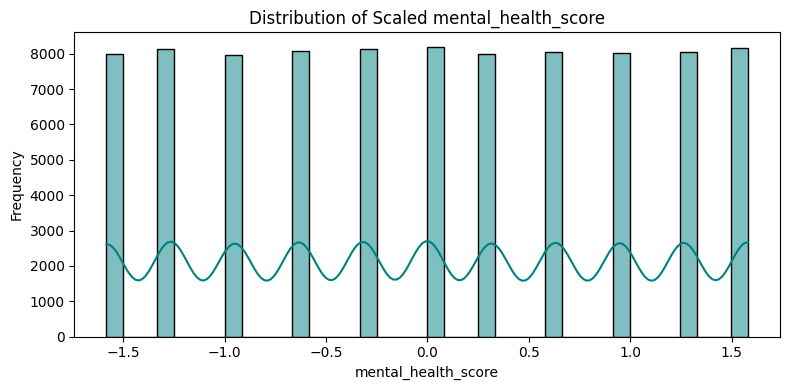

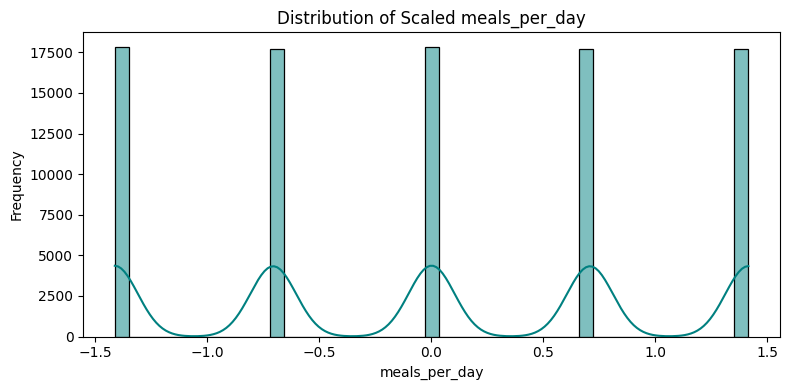

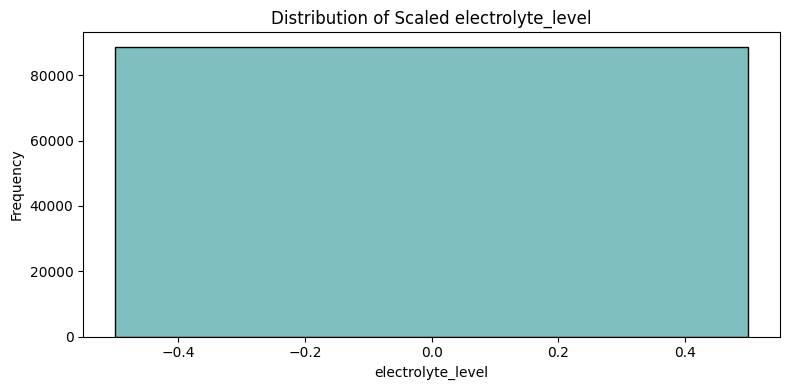

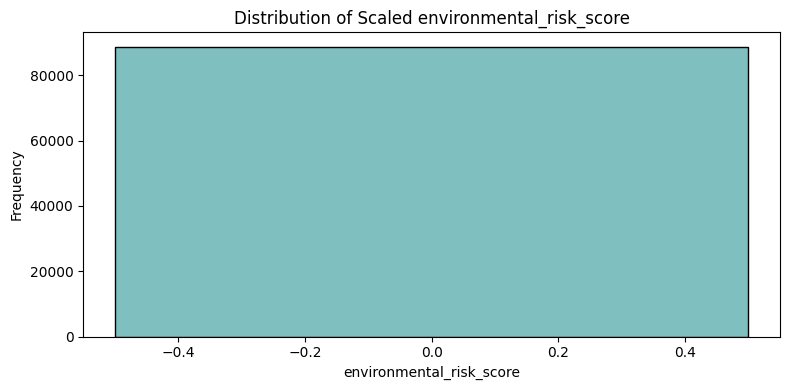

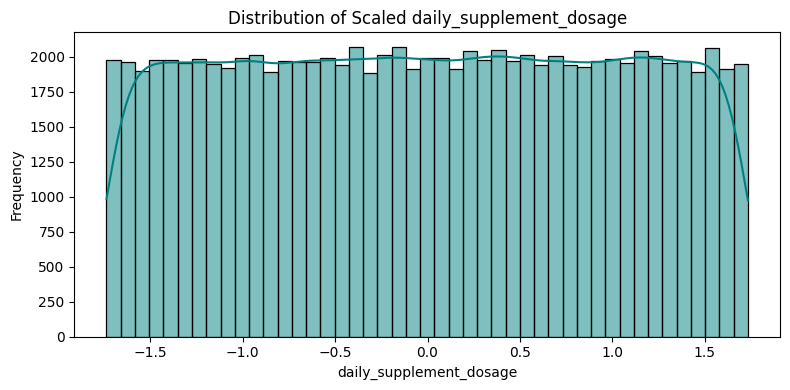

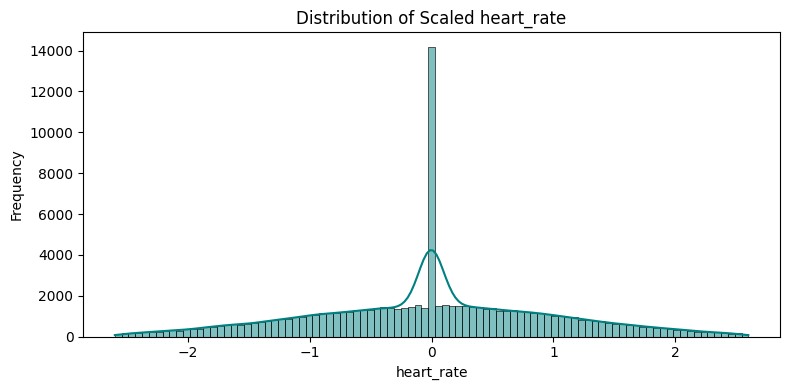

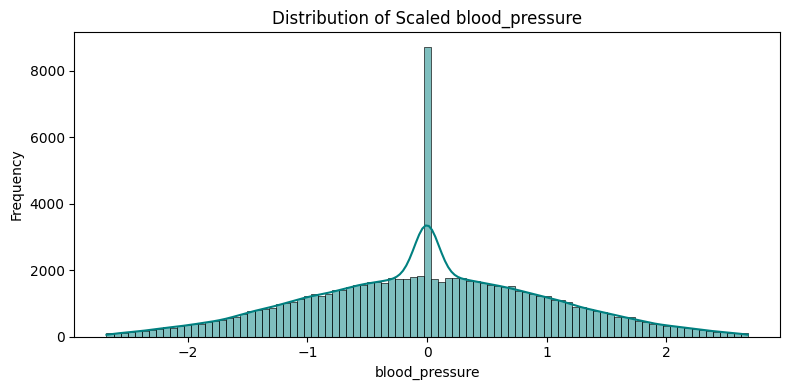

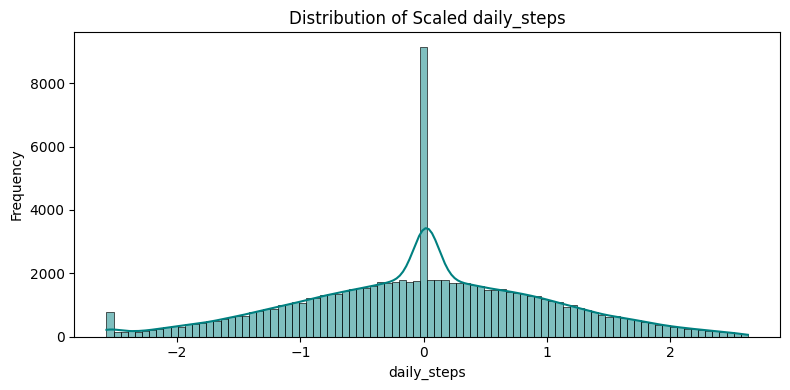

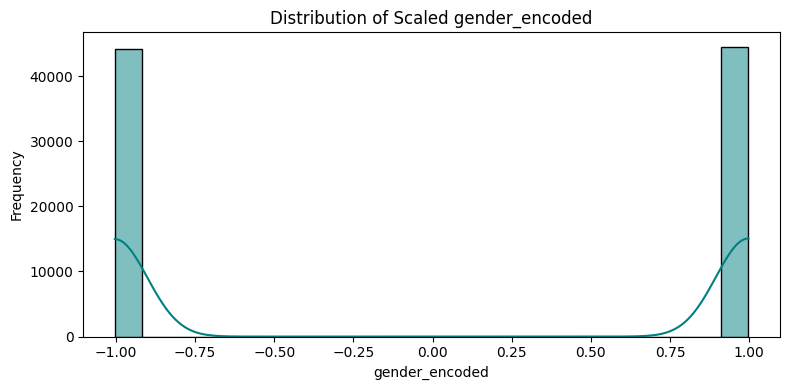

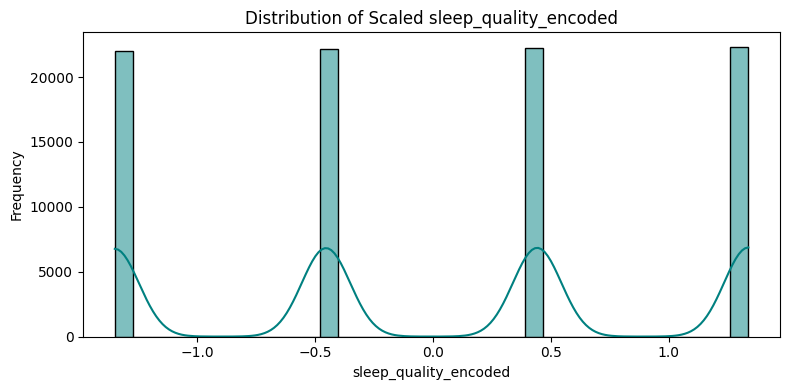

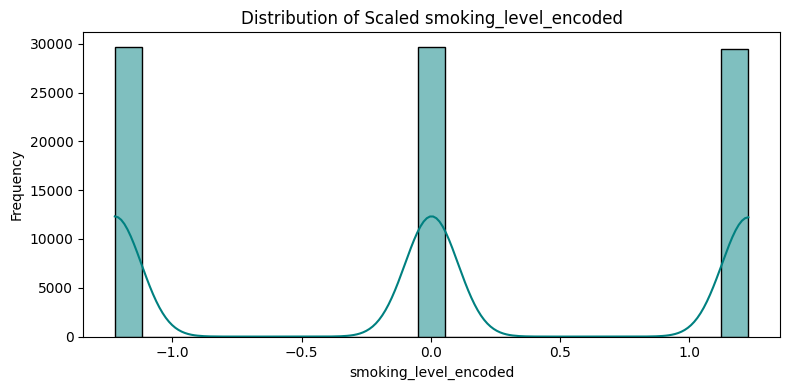

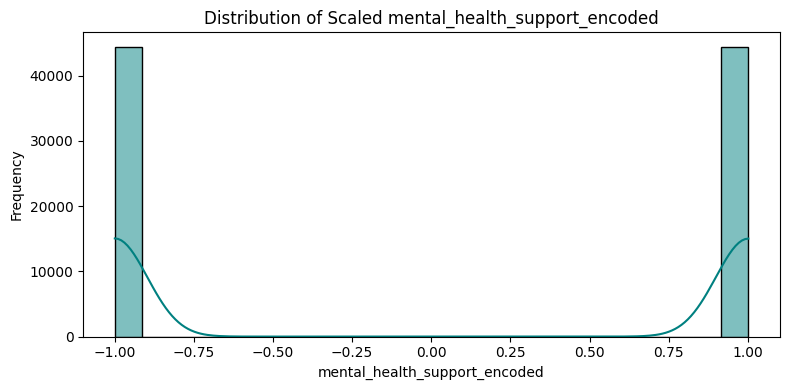

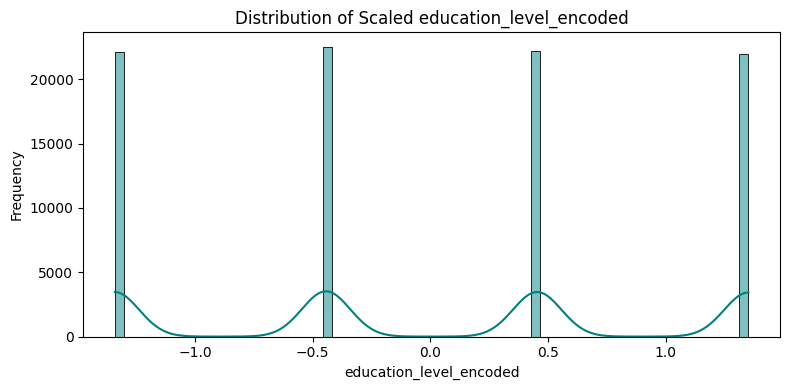

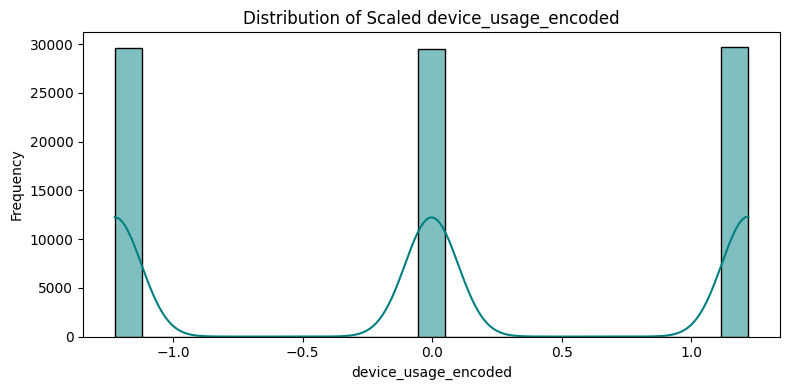

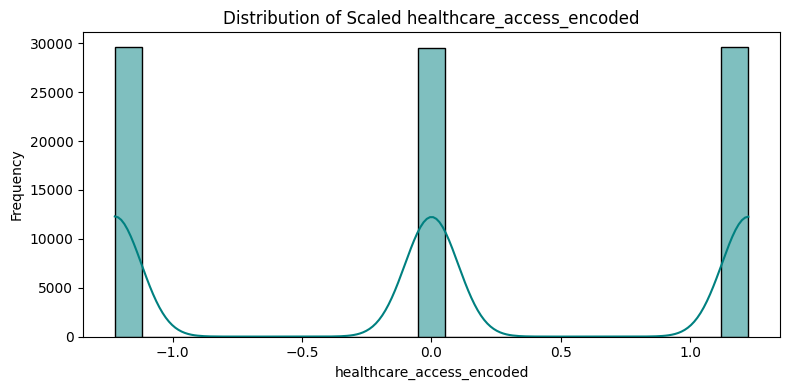

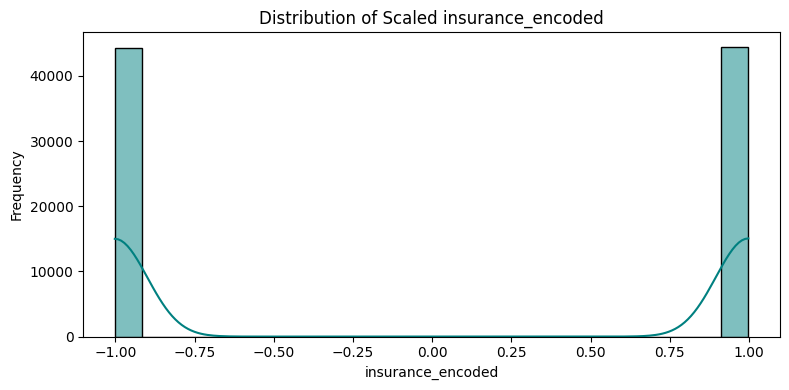

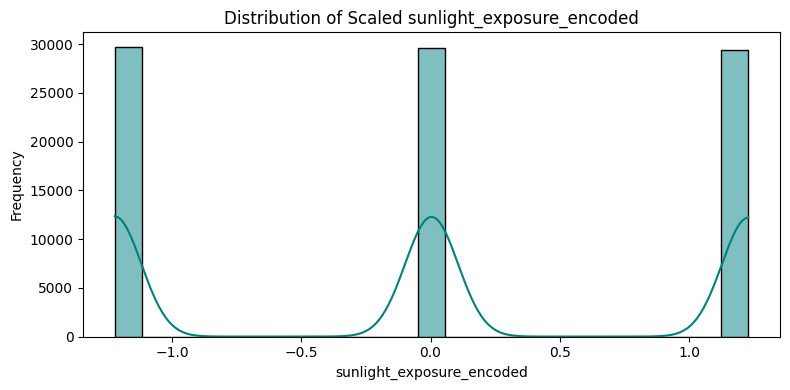

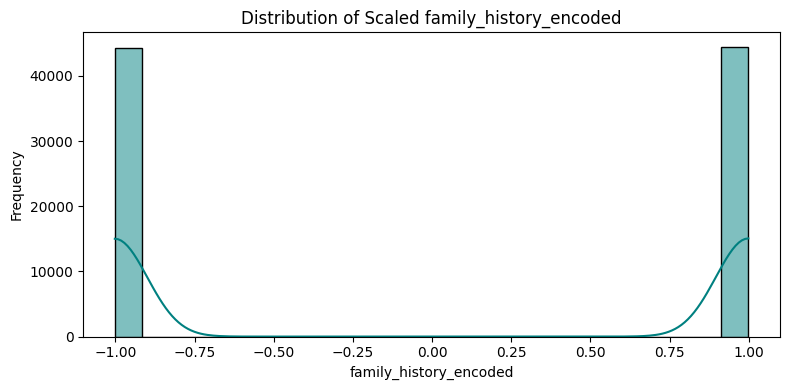

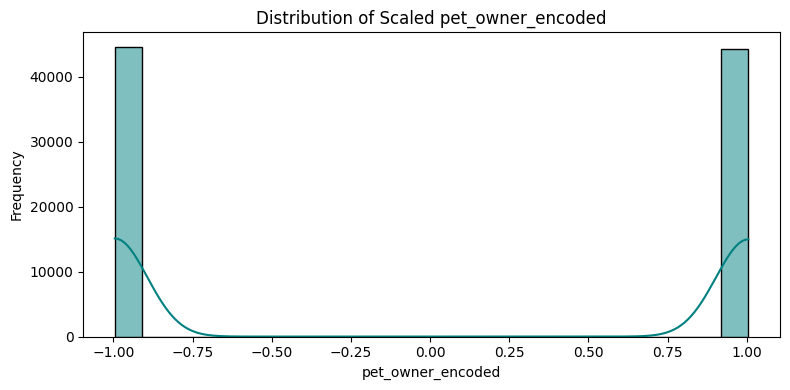

In [84]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select only numeric columns (excluding target)
X = df.select_dtypes(include='number').drop(columns=['target_encoded'])
y = df['target_encoded']  # Target variable

# Step 2: Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Convert scaled data back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Step 4: Visualize distributions of scaled features
for col in X_scaled_df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_scaled_df[col], kde=True, color='teal')
    plt.title(f'Distribution of Scaled {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Step 5: (Optional) Convert resampled data to DataFrame if SMOTE was applied earlier
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_df = pd.Series(y_resampled, name='target_encoded')

In [65]:
#Model_Selection

In [85]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

# Step 1: Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Step 2: Encode categorical columns
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Step 3: Define features and target
X = df_encoded.drop(columns=['target_encoded'])
y = df_encoded['target_encoded']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5a: Logistic Regression (for classification)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))

# Step 5b: Linear Regression (for regression)
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_preds = lin_model.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, lin_preds))

Logistic Regression Accuracy: 1.0
Linear Regression MSE: 2.476161457200878e-25


In [86]:
# Select final features and target
X = df_encoded.drop(columns=['target_encoded'])  # encoded and scaled DataFrame
y = df_encoded['target_encoded']

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y)

In [88]:
# 📦 Import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 📦 Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# ✅ Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

# ✅ Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)              # Train the model
    preds = model.predict(X_test)            # Predict on test set
    
    print(f"\n🔍 {name}")
    print("Accuracy:", accuracy_score(y_test, preds))           # Print accuracy
    print(classification_report(y_test, preds))               # Detailed metrics


🔍 Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5304
           1       1.00      1.00      1.00     12447

    accuracy                           1.00     17751
   macro avg       1.00      1.00      1.00     17751
weighted avg       1.00      1.00      1.00     17751


🔍 Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5304
           1       1.00      1.00      1.00     12447

    accuracy                           1.00     17751
   macro avg       1.00      1.00      1.00     17751
weighted avg       1.00      1.00      1.00     17751


🔍 SVM
Accuracy: 0.7011999323981748
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5304
           1       0.70      1.00      0.82     12447

    accuracy                           0.70     17751
   macro avg       0.35 

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [90]:
print(df_selected.columns)

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'glucose',
       'sleep_hours', 'physical_activity', 'water_intake', 'meals_per_day',
       'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded',
       'family_history_encoded', 'target_encoded'],
      dtype='object')


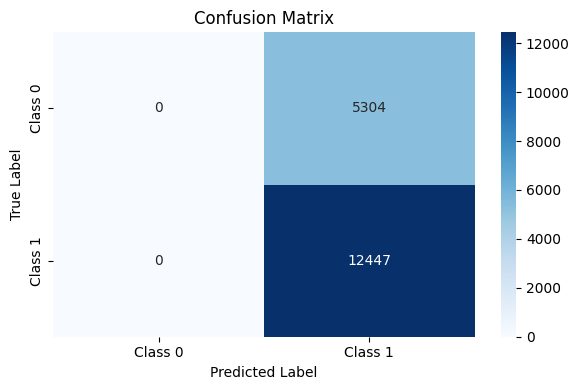

In [91]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Optional: define class labels if known
class_names = ['Class 0', 'Class 1']  # Update if you have more classes

# Compute confusion matrix
cm = confusion_matrix(y_test, preds)

# Create heatmap
plt.figure(figsize=(6, 4))  # Optional: adjust size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [93]:
import joblib
joblib.dump(models['Random Forest'], 'health_model.pkl')


['health_model.pkl']

In [98]:
import pandas as pd
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler

# 🔁 Step 1: Load the trained model
model = joblib.load('health_model.pkl')

# 🧠 Step 2: Extract expected feature names from the trained model
expected_columns = model.feature_names_in_

# 📥 Step 3: Create new input data with known values
new_data = pd.DataFrame([{
    'age': 25,
    'height': 170,
    'weight': 65,
    'bmi': 22.5,
    'waist_size': 80,
    'glucose': 90,
    'sleep_hours': 7,
    'physical_activity': 3,
    'water_intake': 2.5,
    'meals_per_day': 3,
    'heart_rate': 72,
    'blood_pressure': 120,
    'daily_steps': 8000,
    'gender_encoded': 1,
    'family_history_encoded': 0,
    'bmi_corrected': 22.5,
    'bmi_estimated': 22.5,
    'bmi_scaled': 0.0,
    'calorie_intake': 2000,
    'cholesterol': 180,
    'target_encoded': 0  # ✅ Include if used during training
}])

# 🧩 Step 4: Create full input with all expected columns
full_input = pd.DataFrame(columns=expected_columns)
full_input.loc[0] = np.nan  # Initialize with NaN
full_input.update(new_data)  # Fill known values

# 🧼 Step 5: Fill missing values with 0 or domain-specific defaults
full_input.fillna(0, inplace=True)

# 📐 Step 6: Scale input and preserve column names
scaler = StandardScaler()
scaled_array = scaler.fit_transform(full_input)
scaled_df = pd.DataFrame(scaled_array, columns=full_input.columns)

# 🔮 Step 7: Make prediction
prediction = model.predict(scaled_df)
print("Predicted class:", prediction[0])

Predicted class: 0
